### pegar stocks com mais de 1B em Market Cap

In [28]:
import pandas as pd
import requests
import yfinance as yf
from yahoo_fin import stock_info as si
from tqdm import tqdm

# -----------------------------
# 1) S&P 500 da Wikipedia
# -----------------------------
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

html = requests.get(url, headers=headers, timeout=30).text
sp500 = pd.read_html(html)[0]

sp500_tickers = sp500["Symbol"].astype(str).str.replace(".", "-", regex=False).tolist()

print("S&P 500 tickers:", len(sp500_tickers))

# -----------------------------
# 2) Nasdaq do yahoo_fin
# -----------------------------
nasdaq_tickers = list(set(si.tickers_nasdaq()))
nasdaq_tickers = [str(t).replace(".", "-") for t in nasdaq_tickers]

print("Nasdaq tickers:", len(nasdaq_tickers))

# -----------------------------
# 3) Unir
# -----------------------------
all_tickers = set(sorted(set(sp500_tickers) | set(nasdaq_tickers)))

print("Union total:", len(all_tickers))

C:\Users\savio\AppData\Local\Temp\ipykernel_12140\1389275819.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500 = pd.read_html(html)[0]


S&P 500 tickers: 503
Nasdaq tickers: 5381
Union total: 5724


In [29]:
results = []

for t in tqdm(all_tickers):
    try:
        info = yf.Ticker(t).info
        market_cap = info.get("marketCap")
        quote_type = info.get("quoteType")
        
        # manter só equities e market cap > 1B
        if quote_type == "EQUITY" and market_cap is not None and market_cap > 1e9:
            results.append({
                "ticker": t,
                "market_cap": market_cap
            })
    except:
        pass

df = pd.DataFrame(results).drop_duplicates(subset="ticker")
df = df.sort_values("market_cap", ascending=False)

print("Total equities > 1B:", len(df))

df.to_csv("sp500_nasdaq_gt1b_today.csv", index=False)

100%|██████████| 5724/5724 [56:53<00:00,  1.68it/s]


Total equities > 1B: 1375


In [30]:
tickers_final = df["ticker"].tolist()

prices_1995_2007 = yf.download(
    tickers_final,
    start="1995-01-01",
    end="2008-01-01",
    auto_adjust=True,
    progress=True
)["Close"]

prices_1995_2007.to_csv("prices_1995_2007_eua.csv")

prices_1995_2025 = yf.download(
    tickers_final,
    start="1995-01-01",
    end="2025-12-31",
    auto_adjust=True,
    progress=True
)["Close"]

prices_1995_2025.to_csv("prices_1995_2025_eua.csv")

[                       0%                       ]  3 of 1375 completed$TNGX: possibly delisted; no price data found  (1d 1995-01-01 -> 2008-01-01) (Yahoo error = "Data doesn't exist for startDate = 788936400, endDate = 1199163600")
[                       0%                       ]  4 of 1375 completed$NNE: possibly delisted; no price data found  (1d 1995-01-01 -> 2008-01-01) (Yahoo error = "Data doesn't exist for startDate = 788936400, endDate = 1199163600")
[                       0%                       ]  5 of 1375 completed$RZLV: possibly delisted; no price data found  (1d 1995-01-01 -> 2008-01-01) (Yahoo error = "Data doesn't exist for startDate = 788936400, endDate = 1199163600")
[                       0%                       ]  6 of 1375 completed$LNTH: possibly delisted; no price data found  (1d 1995-01-01 -> 2008-01-01) (Yahoo error = "Data doesn't exist for startDate = 788936400, endDate = 1199163600")
[                       1%                       ]  9 of 1375 complet

In [ ]:
data = pd.read_csv("prices_1995_2007_eua.csv", index_col=0, parse_dates=True)
data

,A,AAL,AAOI,AAON,AAPG,AAPL,ABBV,ABCL,ABNB,ABT,...,ZBIO,ZBRA,ZD,ZG,ZION,ZLAB,ZM,ZS,ZTS,ZYME
Date,,,,,,,,,,,,,,,,,,,,,
1995-01-03,NaN,NaN,NaN,0.574862,NaN,0.284213,NaN,NaN,NaN,3.442046,...,NaN,8.333333,NaN,NaN,5.037948,NaN,NaN,NaN,NaN,NaN
1995-01-04,NaN,NaN,NaN,0.624137,NaN,0.291620,NaN,NaN,NaN,3.442046,...,NaN,8.222222,NaN,NaN,4.942402,NaN,NaN,NaN,NaN,NaN
1995-01-05,NaN,NaN,NaN,0.596762,NaN,0.287916,NaN,NaN,NaN,3.415770,...,NaN,8.222222,NaN,NaN,4.985834,NaN,NaN,NaN,NaN,NaN
1995-01-06,NaN,NaN,NaN,0.613187,NaN,0.311061,NaN,NaN,NaN,3.363219,...,NaN,8.222222,NaN,NaN,4.985834,NaN,NaN,NaN,NaN,NaN
1995-01-09,NaN,NaN,NaN,0.613187,NaN,0.305159,NaN,NaN,NaN,3.356877,...,NaN,8.305556,NaN,NaN,5.037948,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,138.113159,15.60,40.639999,75.250000,27.879999,272.105377,226.963898,3.69,136.490005,123.912323,...,42.810001,246.759995,34.720001,68.169998,58.836105,17.480000,87.160004,229.320007,123.014725,26.790001
2025-12-24,138.073227,15.68,41.000000,75.790001,27.879999,273.554016,228.055130,3.72,136.779999,124.180954,...,43.169998,245.899994,35.230000,68.849998,59.124031,18.580000,87.790001,229.600006,124.956429,26.860001
2025-12-26,138.143097,15.44,37.169998,75.769997,27.680000,273.144409,228.144394,3.58,136.820007,124.210808,...,42.490002,246.270004,35.849998,69.589996,59.084316,18.330000,88.040001,230.520004,125.693283,26.870001


In [1]:
import pandas as pd
import requests
import yfinance as yf
from yahoo_fin import stock_info as si
from tqdm import tqdm

# Carregar dados
start_date = "1995-01-02"
end_date = "2008-01-03"

data = pd.read_csv("prices_1995_2007_eua.csv", index_col=0, parse_dates=True)
data.index = pd.to_datetime(data.index)
data = data.sort_index()

returns = data.pct_change()
# returns.dropna(inplace=True,axis=0, how='all')
# returns.dropna(inplace=True,axis=1, how='any')

# Baixar dados do SPY para o mesmo período
data_spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True)["Close"]
data_spy.index = pd.to_datetime(data_spy.index)
data_spy = data_spy.sort_index()
returns_spy = data_spy.pct_change()
returns_spy.dropna(inplace=True)

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns.index     = pd.to_datetime(returns.index).tz_localize(None)
returns_spy.index = pd.to_datetime(returns_spy.index).tz_localize(None)
returns     = returns.sort_index()
returns_spy = returns_spy.sort_index()

returns

Warning - Certain functionality 
             requires requests_html, which is not installed.
             
             Install using: 
             pip install requests_html
             
             After installation, you may have to restart your Python session.


C:\Users\savio\AppData\Local\Temp\ipykernel_3520\1643371246.py:15: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change()
[*********************100%***********************]  1 of 1 completed


,A,AAL,AAOI,AAON,AAPG,AAPL,ABBV,ABCL,ABNB,ABT,...,ZBIO,ZBRA,ZD,ZG,ZION,ZLAB,ZM,ZS,ZTS,ZYME
Date,,,,,,,,,,,,,,,,,,,,,
1995-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-04,NaN,NaN,NaN,0.085715,NaN,0.026060,NaN,NaN,NaN,0.000000,...,NaN,-0.013333,NaN,NaN,-0.018965,NaN,NaN,NaN,NaN,NaN
1995-01-05,NaN,NaN,NaN,-0.043860,NaN,-0.012700,NaN,NaN,NaN,-0.007634,...,NaN,0.000000,NaN,NaN,0.008787,NaN,NaN,NaN,NaN,NaN
1995-01-06,NaN,NaN,NaN,0.027524,NaN,0.080387,NaN,NaN,NaN,-0.015385,...,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
1995-01-09,NaN,NaN,NaN,0.000000,NaN,-0.018974,NaN,NaN,NaN,-0.001886,...,NaN,0.010135,NaN,NaN,0.010453,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2007-12-24,-0.005646,0.037662,NaN,0.040758,NaN,0.025218,NaN,NaN,NaN,0.001545,...,NaN,0.014723,-0.003637,NaN,0.009301,NaN,NaN,NaN,NaN,NaN
2007-12-26,0.013250,-0.016271,NaN,-0.038707,NaN,0.000755,NaN,NaN,NaN,-0.008055,...,NaN,0.001991,0.008668,NaN,-0.014950,NaN,NaN,NaN,NaN,NaN
2007-12-27,-0.008807,-0.034351,NaN,-0.041213,NaN,-0.001910,NaN,NaN,NaN,-0.015549,...,NaN,-0.026973,-0.000453,NaN,-0.037006,NaN,NaN,NaN,NaN,NaN


### Notebook de testes para encontrar o melhor backtest do modelo

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import bs4 as bs
import seaborn as sns
import requests
import time
import requests
import optuna
import threading

from funcoes import (
    pca_portfolio_hedge,
    stats_from_returns,
    pca_portfolio_adaptive_pcs,
    pca_portfolio_quantil
)

from analise_estrategia import analyze_strategy 

d:\savio\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Carregar dados
start_date = "1997-01-02"
end_date = "2007-12-31"

#data = pd.read_csv("dados_full_1997_2007.csv", index_col=0)
data = pd.read_csv("prices_1995_2007_eua.csv", index_col=0)
data.index = pd.to_datetime(data.index)
data = data.sort_index()

returns = data.pct_change()
returns = returns.loc[start_date:end_date]

# Baixar dados do SPY para o mesmo período
data_spy = yf.download("SPY", start=start_date, end=end_date, auto_adjust=True)["Close"]
data_spy.index = pd.to_datetime(data_spy.index)
data_spy = data_spy.sort_index()
returns_spy = data_spy.pct_change()
returns_spy.dropna(inplace=True)

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns.index     = pd.to_datetime(returns.index).tz_localize(None)
returns_spy.index = pd.to_datetime(returns_spy.index).tz_localize(None)
returns     = returns.sort_index()
returns_spy = returns_spy.sort_index()

C:\Users\savio\AppData\Local\Temp\ipykernel_6036\3354090956.py:10: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change()
[*********************100%***********************]  1 of 1 completed


In [3]:
# pegar os tickers e atualizar os dados até 2025
tickers = data.columns.tolist()
len(tickers)

1375

In [4]:
bad_tickers = []

for col in returns.columns:
    p = returns[col]
    if p.min() <= -0.51:  # queda maior que 51% em um dia (ajustado para considerar casos extremos)
        print(f"Ticker {col} tem retorno mínimo <= -0.51, descartando.")
        bad_tickers.append(col)
        continue
    if (p.max() > 0.51):  # variação absurda para cima (ajustado para considerar casos extremos)
        print(f"Ticker {col} tem variação de preço muito grande, descartando.")
        bad_tickers.append(col)

display(bad_tickers)
display(len(bad_tickers))
tickers = list(set(tickers) - set(bad_tickers))
data = data.drop(columns=set(bad_tickers), errors="ignore")
returns = returns.drop(columns=set(bad_tickers), errors="ignore")

len(tickers)

Ticker AAPL tem retorno mínimo <= -0.51, descartando.
Ticker ACAD tem variação de preço muito grande, descartando.
Ticker ACHC tem variação de preço muito grande, descartando.
Ticker ALKS tem retorno mínimo <= -0.51, descartando.
Ticker ALNT tem variação de preço muito grande, descartando.
Ticker ALNY tem variação de preço muito grande, descartando.
Ticker AMKR tem variação de preço muito grande, descartando.
Ticker ANIP tem variação de preço muito grande, descartando.
Ticker ARWR tem retorno mínimo <= -0.51, descartando.
Ticker AXGN tem retorno mínimo <= -0.51, descartando.
Ticker BCRX tem retorno mínimo <= -0.51, descartando.
Ticker CACC tem variação de preço muito grande, descartando.
Ticker CAPR tem variação de preço muito grande, descartando.
Ticker CLDX tem retorno mínimo <= -0.51, descartando.
Ticker CNP tem variação de preço muito grande, descartando.
Ticker CNXN tem retorno mínimo <= -0.51, descartando.
Ticker CORT tem retorno mínimo <= -0.51, descartando.
Ticker CSGS tem vari

['AAPL',
 'ACAD',
 'ACHC',
 'ALKS',
 'ALNT',
 'ALNY',
 'AMKR',
 'ANIP',
 'ARWR',
 'AXGN',
 'BCRX',
 'CACC',
 'CAPR',
 'CLDX',
 'CNP',
 'CNXN',
 'CORT',
 'CSGS',
 'DECK',
 'DRS',
 'DVA',
 'DXPE',
 'ECPG',
 'EEFT',
 'EQIX',
 'EXAS',
 'EZPW',
 'GERN',
 'GGAL',
 'GIII',
 'GILT',
 'HALO',
 'HLIT',
 'IDCC',
 'IDXX',
 'IESC',
 'IMOS',
 'INOD',
 'INSM',
 'IONS',
 'JCI',
 'MANH',
 'MCRI',
 'MSTR',
 'NBIX',
 'NEO',
 'NICE',
 'NTES',
 'NVAX',
 'ON',
 'OPCH',
 'ORKA',
 'OSIS',
 'PFBC',
 'PLUG',
 'PLUS',
 'PWR',
 'QUBT',
 'RCAT',
 'RDNT',
 'REGN',
 'RGEN',
 'RMBS',
 'SBET',
 'SBRA',
 'SIRI',
 'SNEX',
 'SRPT',
 'STRA',
 'STRL',
 'UFPT',
 'UTHR',
 'VCEL',
 'VSEC',
 'WLFC',
 'WMB',
 'ZD']

77

1298

In [5]:
returns.head()

,A,AAL,AAOI,AAON,AAPG,ABBV,ABCL,ABNB,ABT,ABVX,...,ZBH,ZBIO,ZBRA,ZG,ZION,ZLAB,ZM,ZS,ZTS,ZYME
Date,,,,,,,,,,,,,,,,,,,,,
1997-01-02,NaN,NaN,NaN,-0.025641,NaN,NaN,NaN,NaN,-0.007389,NaN,...,NaN,NaN,-0.005348,NaN,-0.012019,NaN,NaN,NaN,NaN,NaN
1997-01-03,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.022332,NaN,...,NaN,NaN,0.037634,NaN,0.015296,NaN,NaN,NaN,NaN,NaN
1997-01-06,NaN,NaN,NaN,0.013158,NaN,NaN,NaN,NaN,-0.012135,NaN,...,NaN,NaN,0.015544,NaN,0.024068,NaN,NaN,NaN,NaN,NaN
1997-01-07,NaN,NaN,NaN,0.012987,NaN,NaN,NaN,NaN,0.022112,NaN,...,NaN,NaN,0.091837,NaN,0.003526,NaN,NaN,NaN,NaN,NaN
1997-01-08,NaN,NaN,NaN,0.076923,NaN,NaN,NaN,NaN,-0.014423,NaN,...,NaN,NaN,-0.018692,NaN,0.015222,NaN,NaN,NaN,NaN,NaN


Tempo : 1997-06-24 00:00:00
Tempo : 1997-06-25 00:00:00
Tempo : 1997-06-26 00:00:00
Tempo : 1997-06-27 00:00:00
Tempo : 1997-06-30 00:00:00
Tempo : 1997-07-01 00:00:00
Tempo : 1997-07-02 00:00:00
Tempo : 1997-07-03 00:00:00
Tempo : 1997-07-07 00:00:00
Tempo : 1997-07-08 00:00:00
Tempo : 1997-07-09 00:00:00
Tempo : 1997-07-10 00:00:00
Tempo : 1997-07-11 00:00:00
Tempo : 1997-07-14 00:00:00
Tempo : 1997-07-15 00:00:00
Tempo : 1997-07-16 00:00:00
Tempo : 1997-07-17 00:00:00
Tempo : 1997-07-18 00:00:00
Tempo : 1997-07-21 00:00:00
Tempo : 1997-07-22 00:00:00
Tempo : 1997-07-23 00:00:00
Tempo : 1997-07-24 00:00:00
Tempo : 1997-07-25 00:00:00
Tempo : 1997-07-28 00:00:00
Tempo : 1997-07-29 00:00:00
Tempo : 1997-07-30 00:00:00
Tempo : 1997-07-31 00:00:00
Tempo : 1997-08-01 00:00:00
Tempo : 1997-08-04 00:00:00
Tempo : 1997-08-05 00:00:00
Tempo : 1997-08-06 00:00:00
Tempo : 1997-08-07 00:00:00
Tempo : 1997-08-08 00:00:00
Tempo : 1997-08-11 00:00:00
Tempo : 1997-08-12 00:00:00
Tempo : 1997-08-13 0

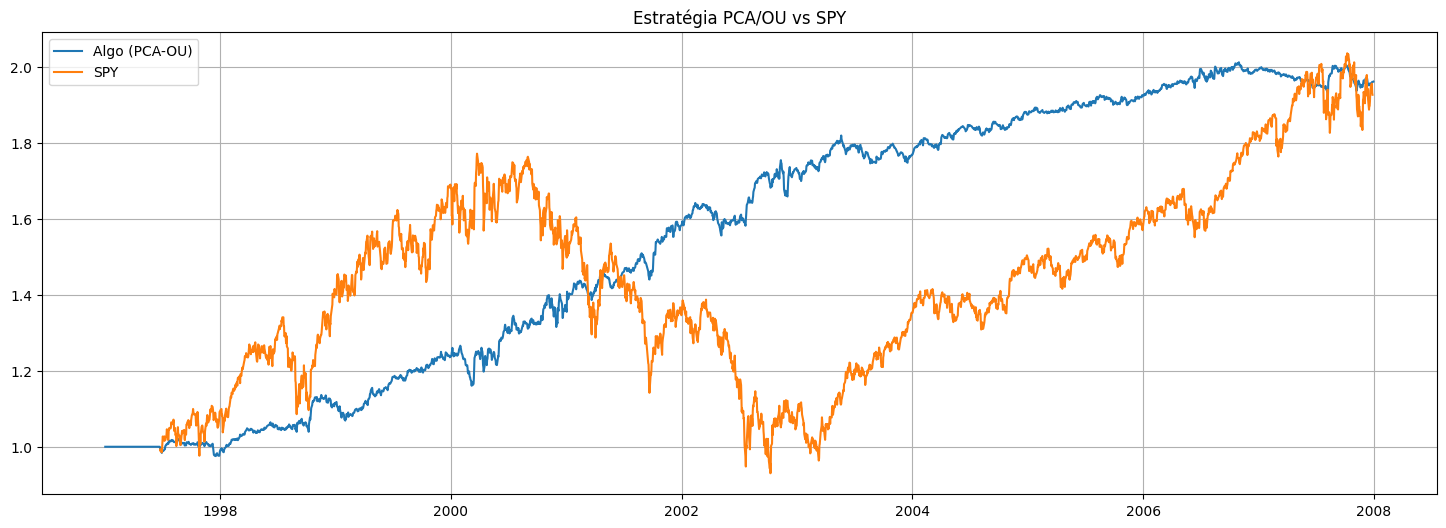

In [10]:
# Melhor (sem drift)
results1 = pca_portfolio_hedge(
    returns=returns,
    returns_bench=returns_spy,
    benchmark="SPY",
    num_pc=10,
    s_win=120,
    window_pca=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    use_drift=False
)

In [17]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net1 = results1['ret_net']
stats1 = stats_from_returns(ret_net1)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats1.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.0633 (   6.33%)
  Vol       :     0.0580 (   5.80%)
  Sharpe    :     1.0909 ( 109.09%)
  MaxDD     :    -0.0832 (  -8.32%)



Tempo : 1997-06-24 00:00:00
Tempo : 1997-06-25 00:00:00
Tempo : 1997-06-26 00:00:00
Tempo : 1997-06-27 00:00:00
Tempo : 1997-06-30 00:00:00
Tempo : 1997-07-01 00:00:00
Tempo : 1997-07-02 00:00:00
Tempo : 1997-07-03 00:00:00
Tempo : 1997-07-07 00:00:00
Tempo : 1997-07-08 00:00:00
Tempo : 1997-07-09 00:00:00
Tempo : 1997-07-10 00:00:00
Tempo : 1997-07-11 00:00:00
Tempo : 1997-07-14 00:00:00
Tempo : 1997-07-15 00:00:00
Tempo : 1997-07-16 00:00:00
Tempo : 1997-07-17 00:00:00
Tempo : 1997-07-18 00:00:00
Tempo : 1997-07-21 00:00:00
Tempo : 1997-07-22 00:00:00
Tempo : 1997-07-23 00:00:00
Tempo : 1997-07-24 00:00:00
Tempo : 1997-07-25 00:00:00
Tempo : 1997-07-28 00:00:00
Tempo : 1997-07-29 00:00:00
Tempo : 1997-07-30 00:00:00
Tempo : 1997-07-31 00:00:00
Tempo : 1997-08-01 00:00:00
Tempo : 1997-08-04 00:00:00
Tempo : 1997-08-05 00:00:00
Tempo : 1997-08-06 00:00:00
Tempo : 1997-08-07 00:00:00
Tempo : 1997-08-08 00:00:00
Tempo : 1997-08-11 00:00:00
Tempo : 1997-08-12 00:00:00
Tempo : 1997-08-13 0

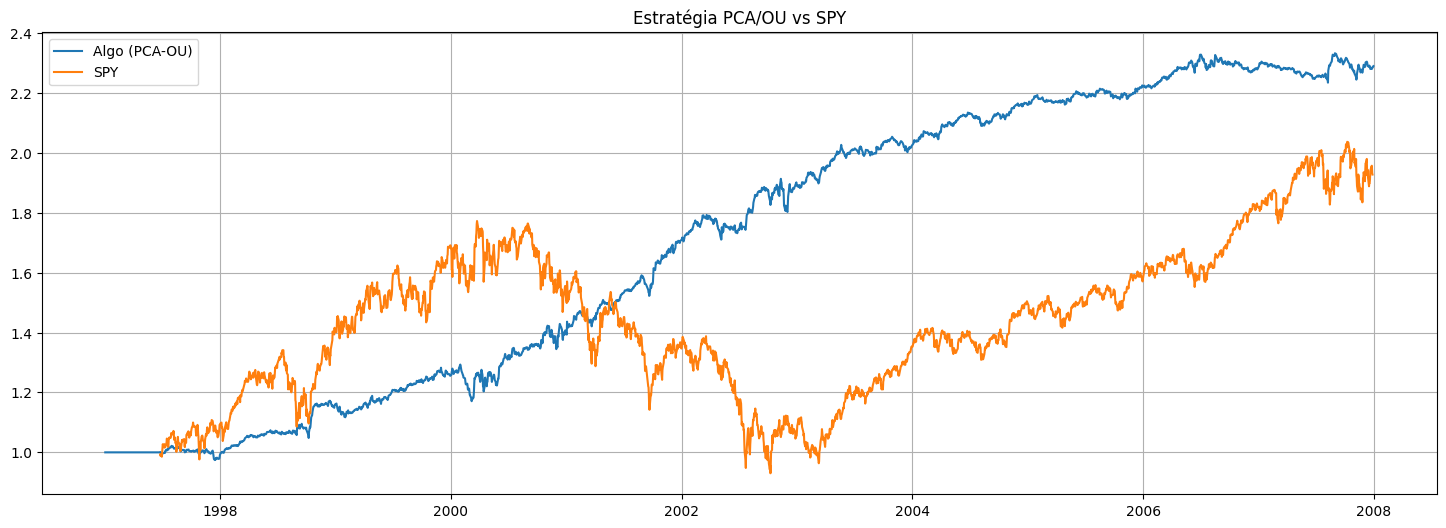

In [22]:
# Melhor (com drift)
results2 = pca_portfolio_hedge(
    returns=returns,
    returns_bench=returns_spy,
    benchmark="SPY",
    num_pc=10,
    s_win=120,
    window_pca=60,
    ma_window=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    use_drift=True
)

In [23]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net2 = results2['ret_net']
stats2 = stats_from_returns(ret_net2)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats2.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.0784 (   7.84%)
  Vol       :     0.0578 (   5.78%)
  Sharpe    :     1.3562 ( 135.62%)
  MaxDD     :    -0.0946 (  -9.46%)



### Testando com PC variáveis e Thresholdes variáveis

Tempo : 1997-06-24 00:00:00
Tempo : 1997-06-25 00:00:00
Tempo : 1997-06-26 00:00:00
Tempo : 1997-06-27 00:00:00
Tempo : 1997-06-30 00:00:00
Tempo : 1997-07-01 00:00:00
Tempo : 1997-07-02 00:00:00
Tempo : 1997-07-03 00:00:00
Tempo : 1997-07-07 00:00:00
Tempo : 1997-07-08 00:00:00
Tempo : 1997-07-09 00:00:00
Tempo : 1997-07-10 00:00:00
Tempo : 1997-07-11 00:00:00
Tempo : 1997-07-14 00:00:00
Tempo : 1997-07-15 00:00:00
Tempo : 1997-07-16 00:00:00
Tempo : 1997-07-17 00:00:00
Tempo : 1997-07-18 00:00:00
Tempo : 1997-07-21 00:00:00
Tempo : 1997-07-22 00:00:00
Tempo : 1997-07-23 00:00:00
Tempo : 1997-07-24 00:00:00
Tempo : 1997-07-25 00:00:00
Tempo : 1997-07-28 00:00:00
Tempo : 1997-07-29 00:00:00
Tempo : 1997-07-30 00:00:00
Tempo : 1997-07-31 00:00:00
Tempo : 1997-08-01 00:00:00
Tempo : 1997-08-04 00:00:00
Tempo : 1997-08-05 00:00:00
Tempo : 1997-08-06 00:00:00
Tempo : 1997-08-07 00:00:00
Tempo : 1997-08-08 00:00:00
Tempo : 1997-08-11 00:00:00
Tempo : 1997-08-12 00:00:00
Tempo : 1997-08-13 0

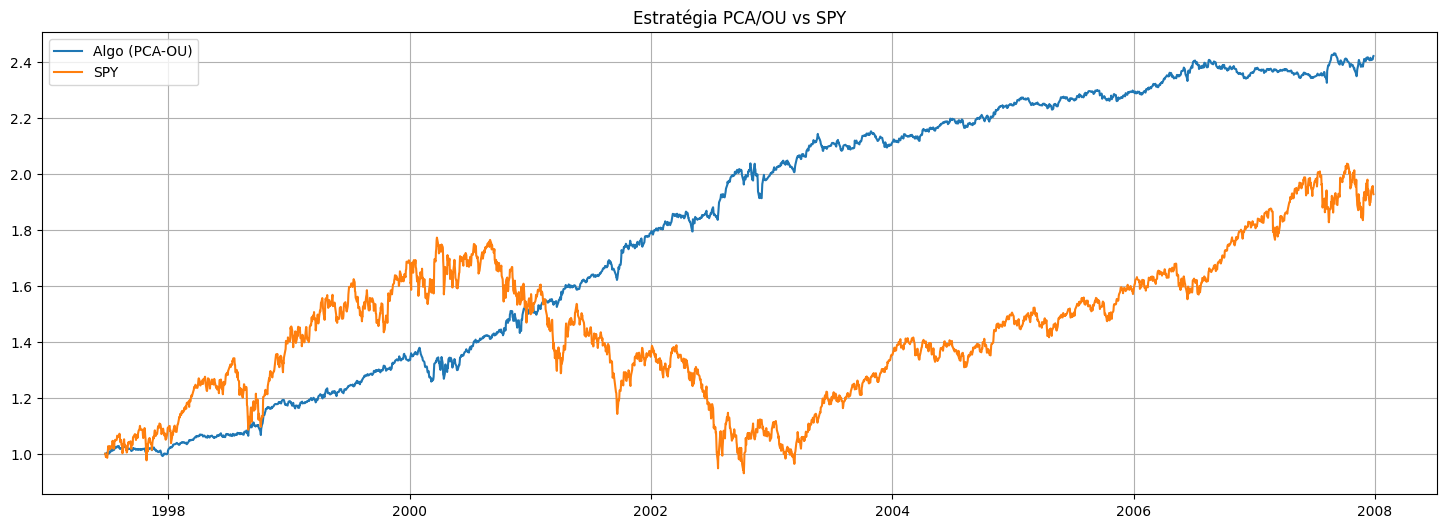

In [6]:
# Melhor
results3 = pca_portfolio_quantil(
    returns=returns,
    returns_bench=returns_spy,
    benchmark="SPY",
    num_pc=10,
    s_win=120,
    window_pca=60,
    ma_window=60,
    adaptive_window=60,
    percentile_open=0.10,
    percentile_close_short=0.45,
    percentile_close_long=0.50,
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    use_drift=True,
    plot=True
)

In [8]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net3 = results3['ret_net']
stats3 = stats_from_returns(ret_net3)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats3.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.0840 (   8.40%)
  Vol       :     0.0563 (   5.63%)
  Sharpe    :     1.4913 ( 149.13%)
  MaxDD     :    -0.0877 (  -8.77%)



Tempo : 1997-06-24 00:00:00
Tempo : 1997-06-25 00:00:00
Tempo : 1997-06-26 00:00:00
Tempo : 1997-06-27 00:00:00
Tempo : 1997-06-30 00:00:00
Tempo : 1997-07-01 00:00:00
Tempo : 1997-07-02 00:00:00
Tempo : 1997-07-03 00:00:00
Tempo : 1997-07-07 00:00:00
Tempo : 1997-07-08 00:00:00
Tempo : 1997-07-09 00:00:00
Tempo : 1997-07-10 00:00:00
Tempo : 1997-07-11 00:00:00
Tempo : 1997-07-14 00:00:00
Tempo : 1997-07-15 00:00:00
Tempo : 1997-07-16 00:00:00
Tempo : 1997-07-17 00:00:00
Tempo : 1997-07-18 00:00:00
Tempo : 1997-07-21 00:00:00
Tempo : 1997-07-22 00:00:00
Tempo : 1997-07-23 00:00:00
Tempo : 1997-07-24 00:00:00
Tempo : 1997-07-25 00:00:00
Tempo : 1997-07-28 00:00:00
Tempo : 1997-07-29 00:00:00
Tempo : 1997-07-30 00:00:00
Tempo : 1997-07-31 00:00:00
Tempo : 1997-08-01 00:00:00
Tempo : 1997-08-04 00:00:00
Tempo : 1997-08-05 00:00:00
Tempo : 1997-08-06 00:00:00
Tempo : 1997-08-07 00:00:00
Tempo : 1997-08-08 00:00:00
Tempo : 1997-08-11 00:00:00
Tempo : 1997-08-12 00:00:00
Tempo : 1997-08-13 0

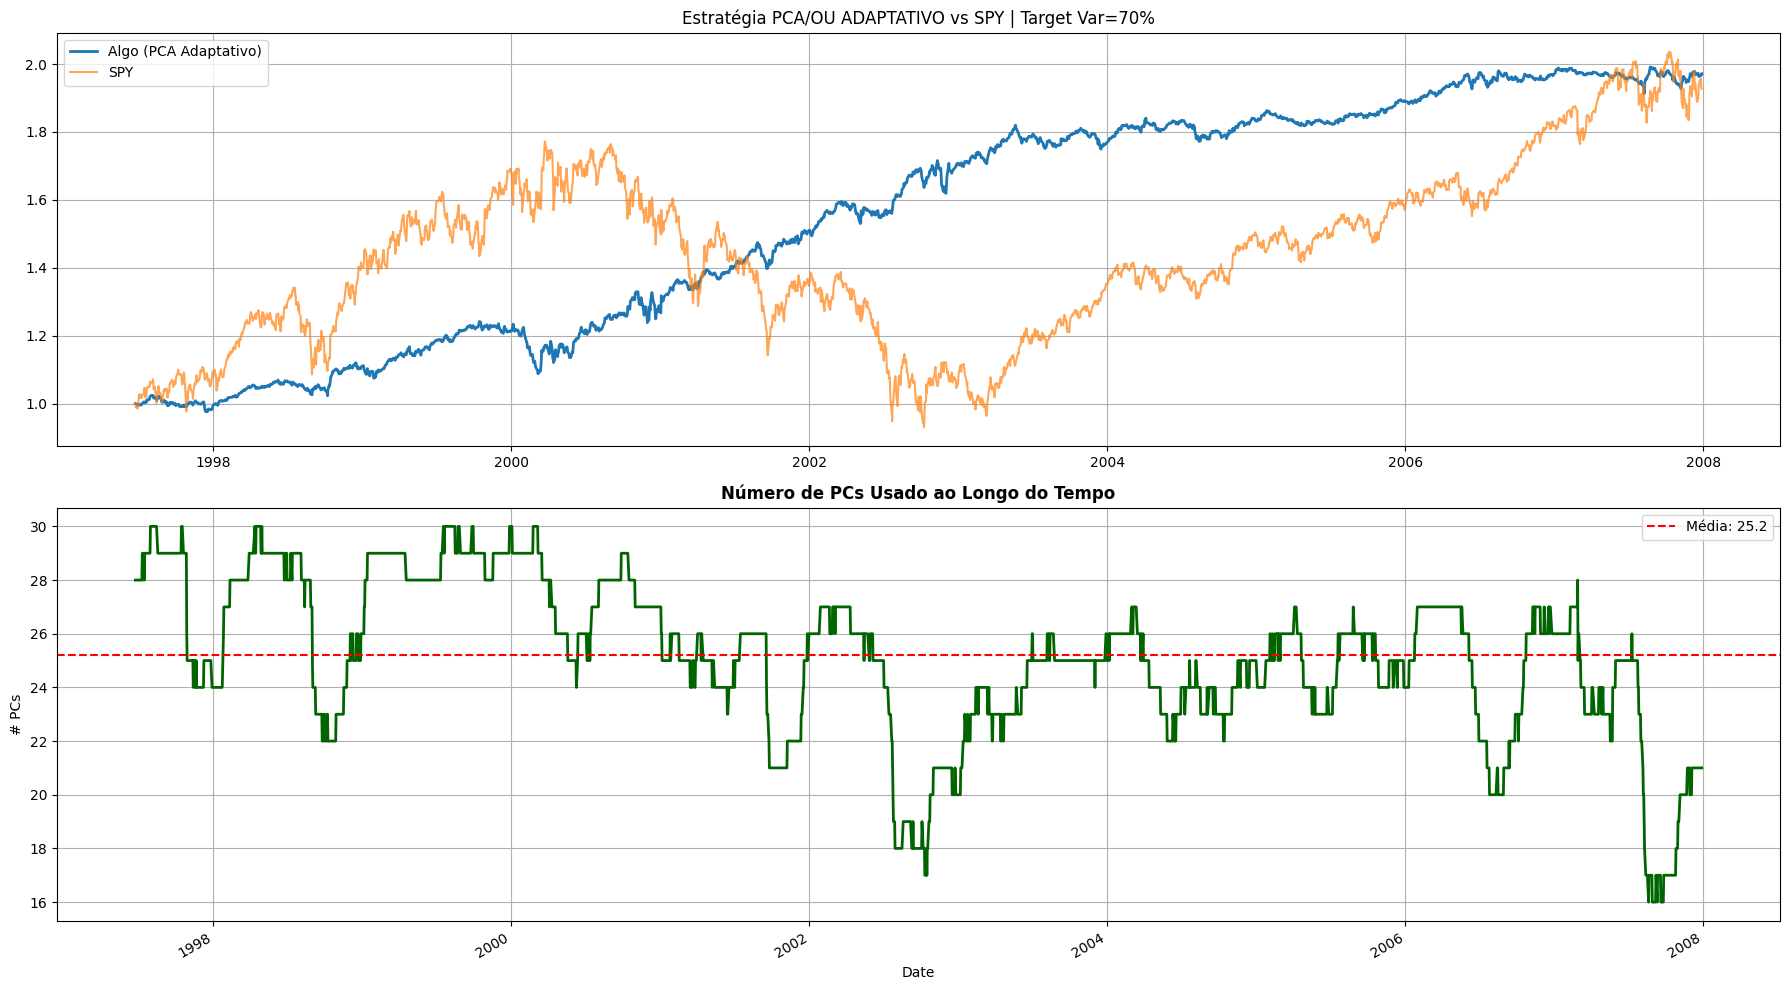

In [9]:
results4 = pca_portfolio_adaptive_pcs(
    returns = returns,
    returns_bench = returns_spy,
    benchmark = "SPY",
    variance_target = 0.70,  
    min_pcs = 5,
    max_pcs = 35,
    s_win = 120,
    window_pca=60,
    ma_window=60,
    adaptive_thresholds = False,
    # thresholds fixos
    sbo = 1.25,
    sso = 1.25,
    sbc = 0.50,
    ssc = 0.50,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    use_drift=True,
    plot = True,
)

In [10]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net4 = results4['ret_net']
stats4 = stats_from_returns(ret_net4)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats4.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.0641 (   6.41%)
  Vol       :     0.0590 (   5.90%)
  Sharpe    :     1.0853 ( 108.53%)
  MaxDD     :    -0.1238 ( -12.38%)



Tempo : 1997-06-24 00:00:00
Tempo : 1997-06-25 00:00:00
Tempo : 1997-06-26 00:00:00
Tempo : 1997-06-27 00:00:00
Tempo : 1997-06-30 00:00:00
Tempo : 1997-07-01 00:00:00
Tempo : 1997-07-02 00:00:00
Tempo : 1997-07-03 00:00:00
Tempo : 1997-07-07 00:00:00
Tempo : 1997-07-08 00:00:00
Tempo : 1997-07-09 00:00:00
Tempo : 1997-07-10 00:00:00
Tempo : 1997-07-11 00:00:00
Tempo : 1997-07-14 00:00:00
Tempo : 1997-07-15 00:00:00
Tempo : 1997-07-16 00:00:00
Tempo : 1997-07-17 00:00:00
Tempo : 1997-07-18 00:00:00
Tempo : 1997-07-21 00:00:00
Tempo : 1997-07-22 00:00:00
Tempo : 1997-07-23 00:00:00
Tempo : 1997-07-24 00:00:00
Tempo : 1997-07-25 00:00:00
Tempo : 1997-07-28 00:00:00
Tempo : 1997-07-29 00:00:00
Tempo : 1997-07-30 00:00:00
Tempo : 1997-07-31 00:00:00
Tempo : 1997-08-01 00:00:00
Tempo : 1997-08-04 00:00:00
Tempo : 1997-08-05 00:00:00
Tempo : 1997-08-06 00:00:00
Tempo : 1997-08-07 00:00:00
Tempo : 1997-08-08 00:00:00
Tempo : 1997-08-11 00:00:00
Tempo : 1997-08-12 00:00:00
Tempo : 1997-08-13 0

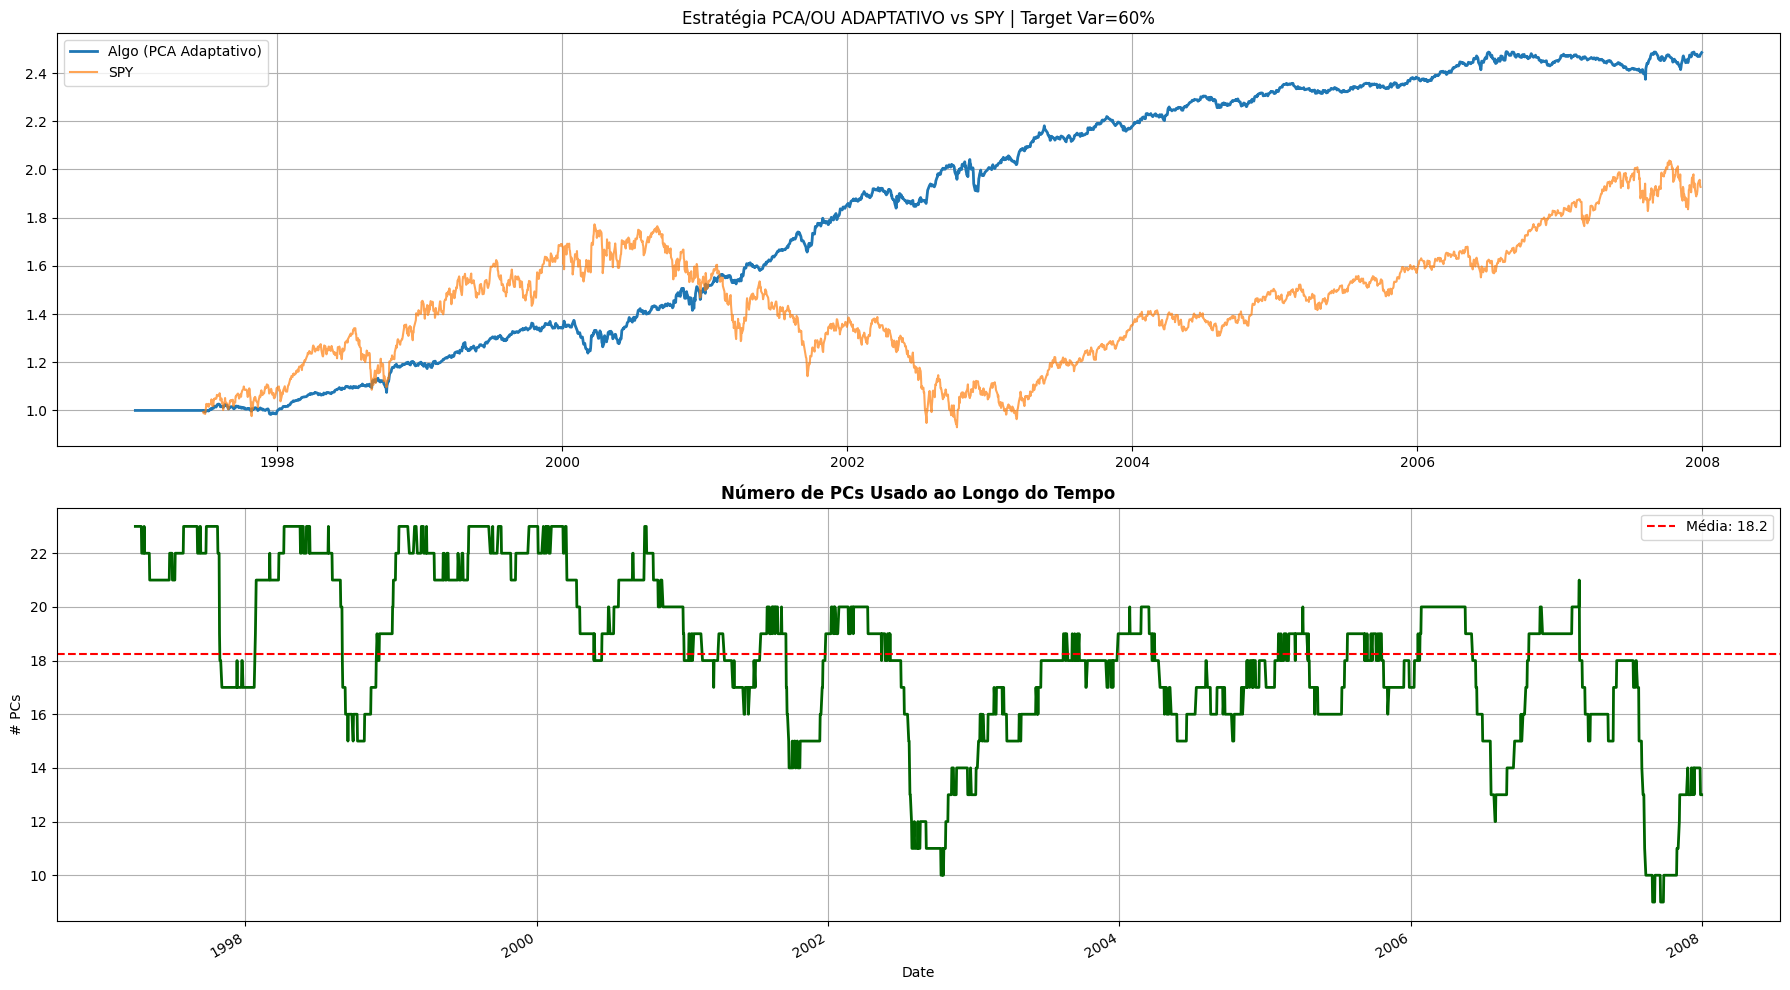

In [9]:
results5 = pca_portfolio_adaptive_pcs(
    returns = returns,
    returns_bench=returns_spy,
    benchmark="SPY",
    variance_target = 0.60,  
    min_pcs = 5,
    max_pcs = 35,
    s_win = 120,
    window_pca=60,
    ma_window=60,
    adaptive_thresholds = True,
    adaptive_window = 60,
    percentile_open = 0.15,
    percentile_close_short = 0.35,
    percentile_close_long = 0.45,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    use_drift=True,
    plot = True,
)

In [26]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net5 = results5['ret_net']
stats5 = stats_from_returns(ret_net5)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats5.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.0864 (   8.64%)
  Vol       :     0.0599 (   5.99%)
  Sharpe    :     1.4425 ( 144.25%)
  MaxDD     :    -0.0991 (  -9.91%)



Tempo : 1997-06-24 00:00:00
Tempo : 1997-06-25 00:00:00
Tempo : 1997-06-26 00:00:00
Tempo : 1997-06-27 00:00:00
Tempo : 1997-06-30 00:00:00
Tempo : 1997-07-01 00:00:00
Tempo : 1997-07-02 00:00:00
Tempo : 1997-07-03 00:00:00
Tempo : 1997-07-07 00:00:00
Tempo : 1997-07-08 00:00:00
Tempo : 1997-07-09 00:00:00
Tempo : 1997-07-10 00:00:00
Tempo : 1997-07-11 00:00:00
Tempo : 1997-07-14 00:00:00
Tempo : 1997-07-15 00:00:00
Tempo : 1997-07-16 00:00:00
Tempo : 1997-07-17 00:00:00
Tempo : 1997-07-18 00:00:00
Tempo : 1997-07-21 00:00:00
Tempo : 1997-07-22 00:00:00
Tempo : 1997-07-23 00:00:00
Tempo : 1997-07-24 00:00:00
Tempo : 1997-07-25 00:00:00
Tempo : 1997-07-28 00:00:00
Tempo : 1997-07-29 00:00:00
Tempo : 1997-07-30 00:00:00
Tempo : 1997-07-31 00:00:00
Tempo : 1997-08-01 00:00:00
Tempo : 1997-08-04 00:00:00
Tempo : 1997-08-05 00:00:00
Tempo : 1997-08-06 00:00:00
Tempo : 1997-08-07 00:00:00
Tempo : 1997-08-08 00:00:00
Tempo : 1997-08-11 00:00:00
Tempo : 1997-08-12 00:00:00
Tempo : 1997-08-13 0

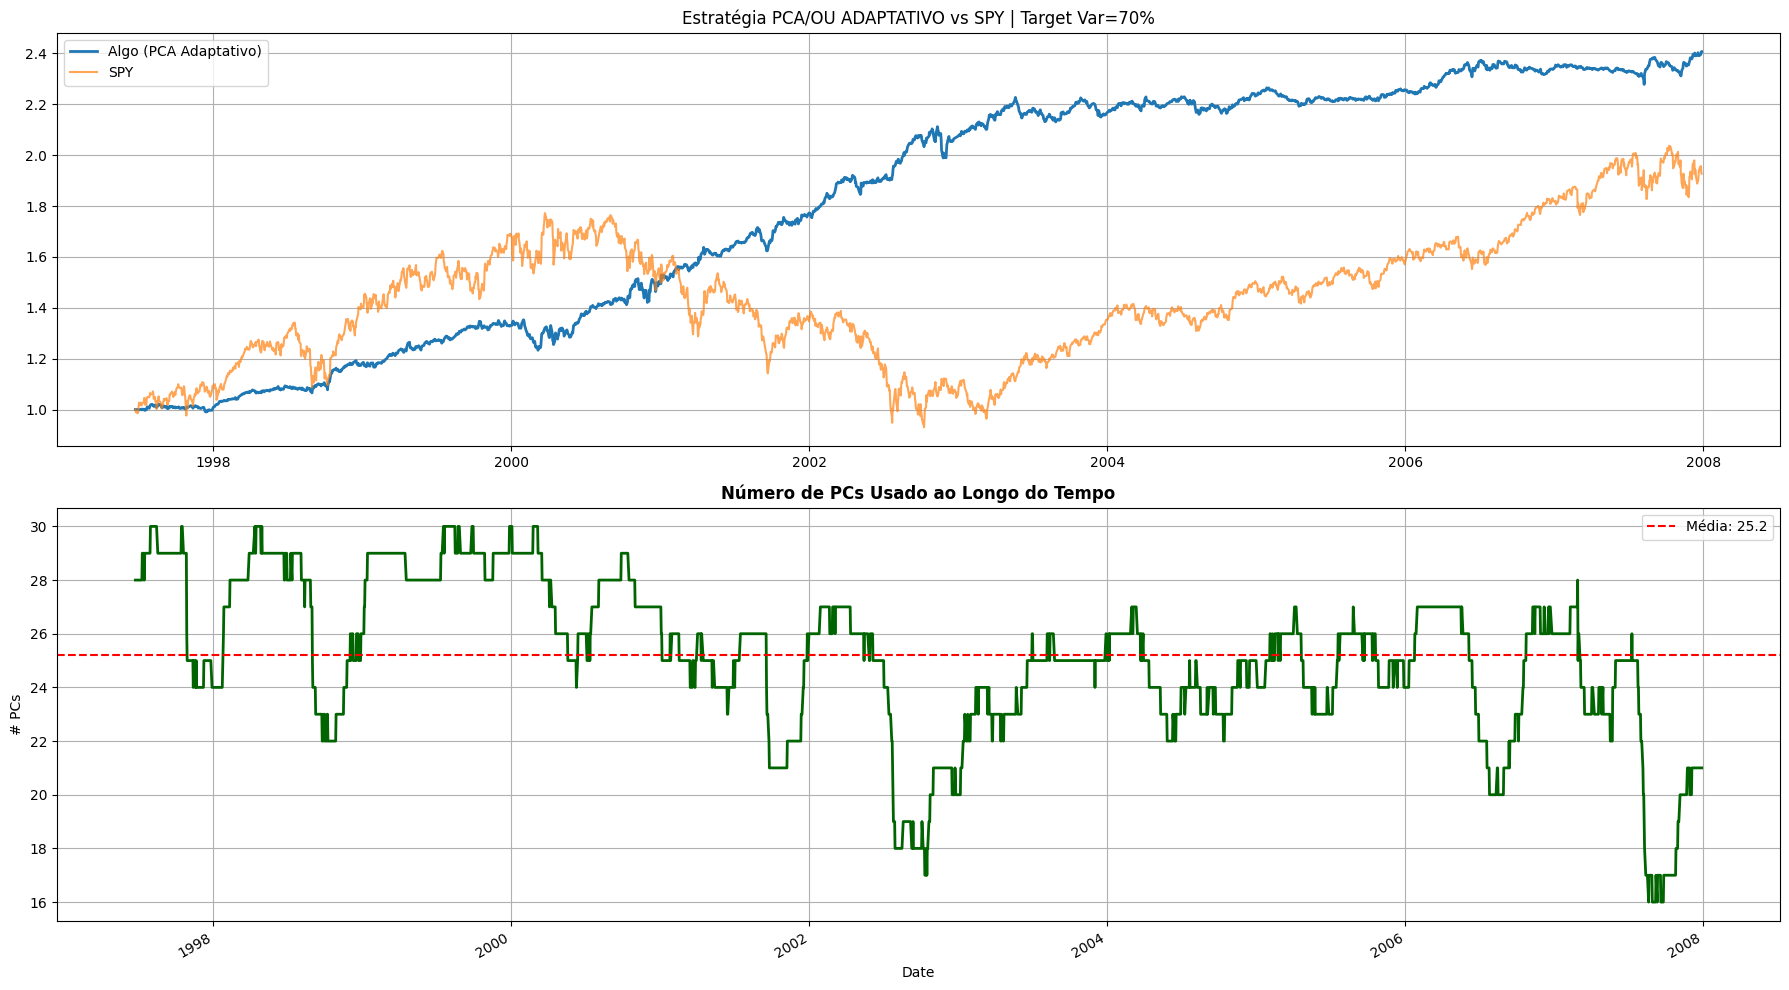

In [11]:
results52 = pca_portfolio_adaptive_pcs(
    returns = returns,
    returns_bench=returns_spy,
    benchmark="SPY",
    variance_target = 0.70,  
    min_pcs = 5,
    max_pcs = 35,
    s_win = 120,
    window_pca=60,
    ma_window=60,
    adaptive_thresholds = True,
    adaptive_window = 60,
    percentile_open = 0.15,
    percentile_close_short = 0.35,
    percentile_close_long = 0.45,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    use_drift=True,
    plot = True,
)

In [12]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net52 = results52['ret_net']
stats52 = stats_from_returns(ret_net52)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats52.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.0835 (   8.35%)
  Vol       :     0.0571 (   5.71%)
  Sharpe    :     1.4628 ( 146.28%)
  MaxDD     :    -0.0884 (  -8.84%)



### Longo prazo

In [13]:
# Carregar dados
#start_date = "1997-01-02"
#end_date = "2007-12-31"

#data_longa = pd.read_csv("dados_1997_2025.csv", index_col=0)
data_longa = pd.read_csv("prices_1995_2025_eua.csv", index_col=0)
returns_longa = data_longa.pct_change()

data_spy_longa = yf.download("SPY", start="1997-01-02", end="2025-12-31", auto_adjust=True)["Close"]
data_spy_longa.index = pd.to_datetime(data_spy_longa.index)
data_spy_longa = data_spy_longa.sort_index()

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns_spy_longa = data_spy_longa.pct_change()
returns_spy_longa.dropna(inplace=True)
returns_longa.index     = pd.to_datetime(returns_longa.index).tz_localize(None)
returns_spy_longa.index = pd.to_datetime(returns_spy_longa.index).tz_localize(None)
returns_longa     = returns_longa.sort_index()
returns_spy_longa = returns_spy_longa.sort_index()

tickers2 = returns_longa.columns.tolist()
len(tickers2)

C:\Users\savio\AppData\Local\Temp\ipykernel_6036\3253324515.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_longa = data_longa.pct_change()
[*********************100%***********************]  1 of 1 completed


1375

In [14]:
bad_tickers2 = []

for col in returns_longa.columns:
    p = returns_longa[col]
    if p.min() <= -0.51:  # queda maior que 51% em um dia (ajustado para considerar casos extremos)
        print(f"Ticker {col} tem retorno mínimo <= -0.51, descartando.")
        bad_tickers2.append(col)
        continue
    if (p.max() > 0.51):  # variação absurda para cima (ajustado para considerar casos extremos)
        print(f"Ticker {col} tem variação de preço muito grande, descartando.")
        bad_tickers2.append(col)

display(bad_tickers2)
display(len(bad_tickers2))
tickers2 = list(set(tickers2) - set(bad_tickers2))
data_longa = data_longa.drop(columns=set(bad_tickers2), errors="ignore")
returns_longa = returns_longa.drop(columns=set(bad_tickers2), errors="ignore")

len(tickers2)

Ticker AAL tem variação de preço muito grande, descartando.
Ticker AAOI tem variação de preço muito grande, descartando.
Ticker AAPL tem retorno mínimo <= -0.51, descartando.
Ticker ABVX tem variação de preço muito grande, descartando.
Ticker ACAD tem retorno mínimo <= -0.51, descartando.
Ticker ACHC tem variação de preço muito grande, descartando.
Ticker ACLS tem retorno mínimo <= -0.51, descartando.
Ticker AEHR tem variação de preço muito grande, descartando.
Ticker AHG tem retorno mínimo <= -0.51, descartando.
Ticker AIG tem retorno mínimo <= -0.51, descartando.
Ticker ALKS tem retorno mínimo <= -0.51, descartando.
Ticker ALM tem variação de preço muito grande, descartando.
Ticker ALNT tem variação de preço muito grande, descartando.
Ticker ALNY tem variação de preço muito grande, descartando.
Ticker AMD tem variação de preço muito grande, descartando.
Ticker AMKR tem variação de preço muito grande, descartando.
Ticker AMLX tem retorno mínimo <= -0.51, descartando.
Ticker AMSC tem v

['AAL',
 'AAOI',
 'AAPL',
 'ABVX',
 'ACAD',
 'ACHC',
 'ACLS',
 'AEHR',
 'AHG',
 'AIG',
 'ALKS',
 'ALM',
 'ALNT',
 'ALNY',
 'AMD',
 'AMKR',
 'AMLX',
 'AMSC',
 'ANAB',
 'ANIP',
 'APA',
 'APLD',
 'ARDX',
 'ARGX',
 'ARLP',
 'ARWR',
 'ASND',
 'ASTH',
 'ASTS',
 'ATEC',
 'ATRC',
 'AUPH',
 'AUR',
 'AXGN',
 'AXSM',
 'AXTI',
 'BBIO',
 'BCRX',
 'BITF',
 'BLDR',
 'BNTX',
 'BULL',
 'BVC',
 'C',
 'CACC',
 'CAMT',
 'CAPR',
 'CAR',
 'CBRE',
 'CELC',
 'CELH',
 'CHEF',
 'CHRD',
 'CLDX',
 'CLMT',
 'CLOV',
 'CLSK',
 'CNP',
 'CNXN',
 'COGT',
 'CORT',
 'CPRX',
 'CRML',
 'CRNX',
 'CRVS',
 'CSGS',
 'CVNA',
 'CWST',
 'CYTK',
 'DAVE',
 'DAWN',
 'DBVT',
 'DECK',
 'DFTX',
 'DHC',
 'DHR',
 'DJT',
 'DMRA',
 'DNTH',
 'DORM',
 'DRH',
 'DRS',
 'DVA',
 'DXPE',
 'ECPG',
 'EEFT',
 'ELVN',
 'ENLT',
 'EQIX',
 'ESTA',
 'EWBC',
 'EWTX',
 'EXAS',
 'EXEL',
 'EYPT',
 'EZPW',
 'FCNCA',
 'FITB',
 'FOLD',
 'GCT',
 'GDS',
 'GERN',
 'GGAL',
 'GIII',
 'GILT',
 'GL',
 'GLUE',
 'GMAB',
 'GPCR',
 'GSAT',
 'GSIW',
 'HALO',
 'HBNB',
 'HEP

299

1076

In [15]:
returns_longa

,A,AAON,AAPG,ABBV,ABCL,ABNB,ABT,ACDC,ACGL,ACGLO,...,ZBH,ZBIO,ZBRA,ZG,ZION,ZLAB,ZM,ZS,ZTS,ZYME
Date,,,,,,,,,,,,,,,,,,,,,
1995-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-04,NaN,0.085715,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,-0.013333,NaN,-0.018965,NaN,NaN,NaN,NaN,NaN
1995-01-05,NaN,-0.043860,NaN,NaN,NaN,NaN,-0.007634,NaN,NaN,NaN,...,NaN,NaN,0.000000,NaN,0.008787,NaN,NaN,NaN,NaN,NaN
1995-01-06,NaN,0.027524,NaN,NaN,NaN,NaN,-0.015385,NaN,NaN,NaN,...,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
1995-01-09,NaN,0.000000,NaN,NaN,NaN,NaN,-0.001886,NaN,NaN,NaN,...,NaN,NaN,0.010135,NaN,0.010453,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,-0.001155,0.002264,0.052473,0.003861,-0.008065,-0.003359,-0.005272,0.007979,-0.001647,-0.004919,...,-0.004120,0.011339,-0.010506,0.003090,-0.015778,-0.012987,-0.031448,-0.011765,-0.001939,-0.030051
2025-12-24,-0.000289,0.007176,0.000000,0.004808,0.008130,0.002125,0.002168,-0.002639,-0.005776,-0.002966,...,0.008946,0.008409,-0.003485,0.009975,0.004894,0.062929,0.007228,0.001221,0.015784,0.002613
2025-12-26,0.000506,-0.000264,-0.007174,0.000391,-0.037634,0.000293,0.000240,-0.007937,-0.005498,0.002975,...,0.005985,-0.015752,0.001505,0.010748,-0.000672,-0.013455,0.002848,0.004007,0.005897,0.000372


Tempo : 1995-06-23 00:00:00
Tempo : 1995-06-26 00:00:00
Tempo : 1995-06-27 00:00:00
Tempo : 1995-06-28 00:00:00
Tempo : 1995-06-29 00:00:00
Tempo : 1995-06-30 00:00:00
Tempo : 1995-07-03 00:00:00
Tempo : 1995-07-05 00:00:00
Tempo : 1995-07-06 00:00:00
Tempo : 1995-07-07 00:00:00
Tempo : 1995-07-10 00:00:00
Tempo : 1995-07-11 00:00:00
Tempo : 1995-07-12 00:00:00
Tempo : 1995-07-13 00:00:00
Tempo : 1995-07-14 00:00:00
Tempo : 1995-07-17 00:00:00
Tempo : 1995-07-18 00:00:00
Tempo : 1995-07-19 00:00:00
Tempo : 1995-07-20 00:00:00
Tempo : 1995-07-21 00:00:00
Tempo : 1995-07-24 00:00:00
Tempo : 1995-07-25 00:00:00
Tempo : 1995-07-26 00:00:00
Tempo : 1995-07-27 00:00:00
Tempo : 1995-07-28 00:00:00
Tempo : 1995-07-31 00:00:00
Tempo : 1995-08-01 00:00:00
Tempo : 1995-08-02 00:00:00
Tempo : 1995-08-03 00:00:00
Tempo : 1995-08-04 00:00:00
Tempo : 1995-08-07 00:00:00
Tempo : 1995-08-08 00:00:00
Tempo : 1995-08-09 00:00:00
Tempo : 1995-08-10 00:00:00
Tempo : 1995-08-11 00:00:00
Tempo : 1995-08-14 0

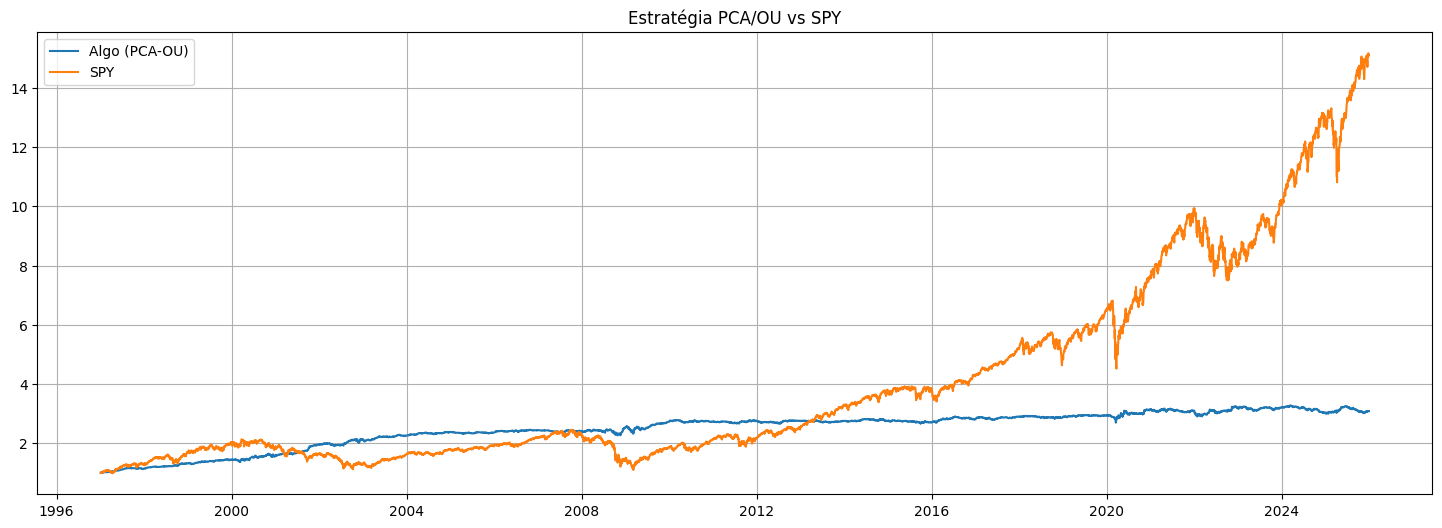

In [5]:
# Melhor longo (sem drift)
results6 = pca_portfolio_hedge(
    returns=returns_longa,
    returns_bench=returns_spy_longa,
    benchmark="SPY",
    num_pc=10,
    s_win=120,
    window_pca=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    use_drift=False
)

In [6]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net6 = results6['ret_net']
stats6 = stats_from_returns(ret_net6)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1997-2025)")
print("="*70)
for k, v in stats6.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1997-2025)
  CAGR      :     0.0427 (   4.27%)
  Vol       :     0.0543 (   5.43%)
  Sharpe    :     0.7862 (  78.62%)
  MaxDD     :    -0.0991 (  -9.91%)



Tempo : 1995-06-23 00:00:00
Tempo : 1995-06-26 00:00:00
Tempo : 1995-06-27 00:00:00
Tempo : 1995-06-28 00:00:00
Tempo : 1995-06-29 00:00:00
Tempo : 1995-06-30 00:00:00
Tempo : 1995-07-03 00:00:00
Tempo : 1995-07-05 00:00:00
Tempo : 1995-07-06 00:00:00
Tempo : 1995-07-07 00:00:00
Tempo : 1995-07-10 00:00:00
Tempo : 1995-07-11 00:00:00
Tempo : 1995-07-12 00:00:00
Tempo : 1995-07-13 00:00:00
Tempo : 1995-07-14 00:00:00
Tempo : 1995-07-17 00:00:00
Tempo : 1995-07-18 00:00:00
Tempo : 1995-07-19 00:00:00
Tempo : 1995-07-20 00:00:00
Tempo : 1995-07-21 00:00:00
Tempo : 1995-07-24 00:00:00
Tempo : 1995-07-25 00:00:00
Tempo : 1995-07-26 00:00:00
Tempo : 1995-07-27 00:00:00
Tempo : 1995-07-28 00:00:00
Tempo : 1995-07-31 00:00:00
Tempo : 1995-08-01 00:00:00
Tempo : 1995-08-02 00:00:00
Tempo : 1995-08-03 00:00:00
Tempo : 1995-08-04 00:00:00
Tempo : 1995-08-07 00:00:00
Tempo : 1995-08-08 00:00:00
Tempo : 1995-08-09 00:00:00
Tempo : 1995-08-10 00:00:00
Tempo : 1995-08-11 00:00:00
Tempo : 1995-08-14 0

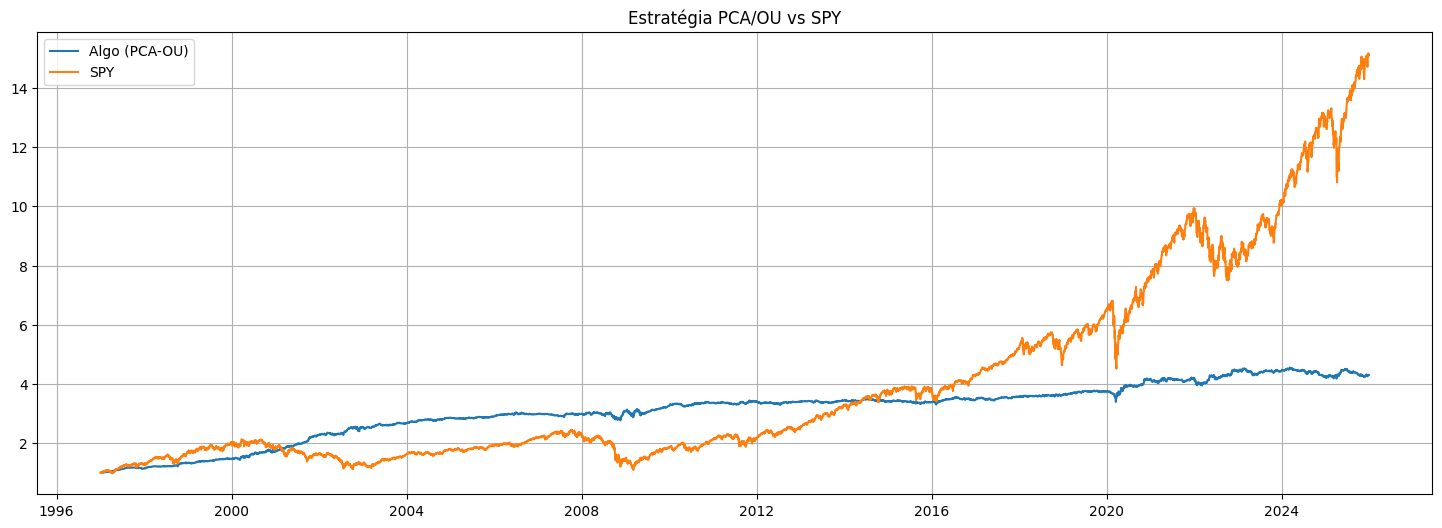

In [7]:
# Melhor longo (com drift)
results62 = pca_portfolio_hedge(
    returns=returns_longa,
    returns_bench=returns_spy_longa,
    benchmark="SPY",
    num_pc=10,
    s_win=120,
    window_pca=60,
    ma_window=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    plot=True,
    use_drift=True
)

In [8]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net62 = results62['ret_net']
stats62 = stats_from_returns(ret_net62)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1997-2025)")
print("="*70)
for k, v in stats62.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1997-2025)
  CAGR      :     0.0560 (   5.60%)
  Vol       :     0.0537 (   5.37%)
  Sharpe    :     1.0436 ( 104.36%)
  MaxDD     :    -0.1023 ( -10.23%)



In [ ]:
results7 = pca_portfolio_quantil(
    returns=returns_longa,
    returns_bench=returns_spy_longa,
    benchmark="SPY",
    num_pc=10,
    s_win=120,
    window_pca=60,
    ma_window=60,
    adaptive_window=60,
    percentile_open=0.10,
    percentile_close_short=0.45,
    percentile_close_long=0.50,
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    use_drift=True,
    plot=True
)

KeyboardInterrupt: 

In [56]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net7 = results7['ret_net']
stats7 = stats_from_returns(ret_net7)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1997-2025)")
print("="*70)
for k, v in stats7.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1997-2025)
  CAGR      :     0.0602 (   6.02%)
  Vol       :     0.0533 (   5.33%)
  Sharpe    :     1.1284 ( 112.84%)
  MaxDD     :    -0.1040 ( -10.40%)



Tempo : 1995-06-23 00:00:00
Tempo : 1995-06-26 00:00:00
Tempo : 1995-06-27 00:00:00
Tempo : 1995-06-28 00:00:00
Tempo : 1995-06-29 00:00:00
Tempo : 1995-06-30 00:00:00
Tempo : 1995-07-03 00:00:00
Tempo : 1995-07-05 00:00:00
Tempo : 1995-07-06 00:00:00
Tempo : 1995-07-07 00:00:00
Tempo : 1995-07-10 00:00:00
Tempo : 1995-07-11 00:00:00
Tempo : 1995-07-12 00:00:00
Tempo : 1995-07-13 00:00:00
Tempo : 1995-07-14 00:00:00
Tempo : 1995-07-17 00:00:00
Tempo : 1995-07-18 00:00:00
Tempo : 1995-07-19 00:00:00
Tempo : 1995-07-20 00:00:00
Tempo : 1995-07-21 00:00:00
Tempo : 1995-07-24 00:00:00
Tempo : 1995-07-25 00:00:00
Tempo : 1995-07-26 00:00:00
Tempo : 1995-07-27 00:00:00
Tempo : 1995-07-28 00:00:00
Tempo : 1995-07-31 00:00:00
Tempo : 1995-08-01 00:00:00
Tempo : 1995-08-02 00:00:00
Tempo : 1995-08-03 00:00:00
Tempo : 1995-08-04 00:00:00
Tempo : 1995-08-07 00:00:00
Tempo : 1995-08-08 00:00:00
Tempo : 1995-08-09 00:00:00
Tempo : 1995-08-10 00:00:00
Tempo : 1995-08-11 00:00:00
Tempo : 1995-08-14 0

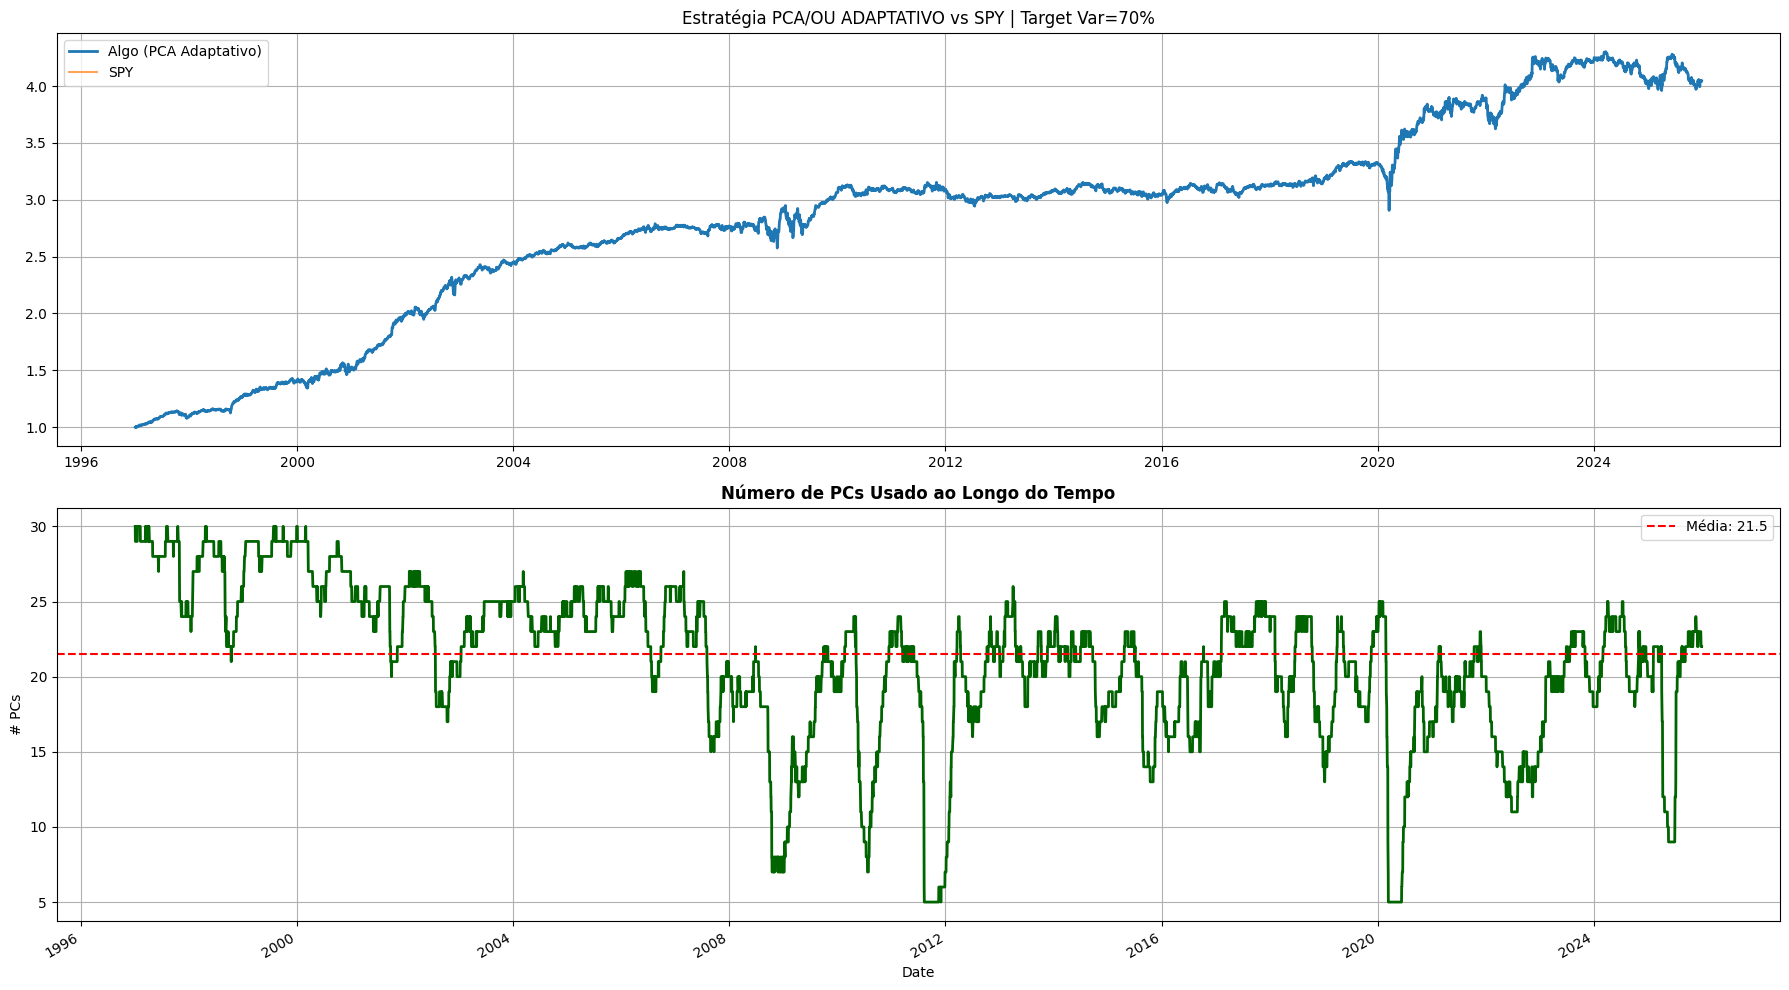

In [ ]:
results8 = pca_portfolio_adaptive_pcs(
    returns = returns_longa,
    returns_bench = returns_spy_longa,
    benchmark = "SPY",
    variance_target = 0.70,
    min_pcs = 5,
    max_pcs = 35,
    s_win = 120,
    window_pca=60,
    ma_window=60,
    adaptive_thresholds = False,
    # thresholds fixos
    sbo = 1.25,
    sso = 1.25,
    sbc = 0.50,
    ssc = 0.50,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    use_drift=True,
    plot = True,
)

In [22]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net8 = results8['ret_net']
stats8 = stats_from_returns(ret_net8)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1997-2025)")
print("="*70)
for k, v in stats8.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1997-2025)
  CAGR      :     0.0507 (   5.07%)
  Vol       :     0.0568 (   5.68%)
  Sharpe    :     0.8931 (  89.31%)
  MaxDD     :    -0.1288 ( -12.88%)



In [ ]:
results9 = pca_portfolio_adaptive_pcs(
    returns = returns_longa,
    returns_bench=returns_spy_longa,
    benchmark="SPY",
    variance_target = 0.70,  
    min_pcs = 5,
    max_pcs = 35,
    s_win = 120,
    window_pca=60,
    ma_window=60,
    adaptive_thresholds = True,
    adaptive_window = 60,
    percentile_open = 0.10,
    percentile_close_short = 0.35,
    percentile_close_long = 0.45,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    use_drift=True,
    plot = True,
)

Tempo : 1995-06-23 00:00:00
Tempo : 1995-06-26 00:00:00
Tempo : 1995-06-27 00:00:00
Tempo : 1995-06-28 00:00:00
Tempo : 1995-06-29 00:00:00
Tempo : 1995-06-30 00:00:00
Tempo : 1995-07-03 00:00:00
Tempo : 1995-07-05 00:00:00
Tempo : 1995-07-06 00:00:00
Tempo : 1995-07-07 00:00:00
Tempo : 1995-07-10 00:00:00
Tempo : 1995-07-11 00:00:00
Tempo : 1995-07-12 00:00:00
Tempo : 1995-07-13 00:00:00
Tempo : 1995-07-14 00:00:00
Tempo : 1995-07-17 00:00:00
Tempo : 1995-07-18 00:00:00
Tempo : 1995-07-19 00:00:00
Tempo : 1995-07-20 00:00:00
Tempo : 1995-07-21 00:00:00
Tempo : 1995-07-24 00:00:00
Tempo : 1995-07-25 00:00:00
Tempo : 1995-07-26 00:00:00
Tempo : 1995-07-27 00:00:00
Tempo : 1995-07-28 00:00:00
Tempo : 1995-07-31 00:00:00
Tempo : 1995-08-01 00:00:00
Tempo : 1995-08-02 00:00:00
Tempo : 1995-08-03 00:00:00
Tempo : 1995-08-04 00:00:00
Tempo : 1995-08-07 00:00:00
Tempo : 1995-08-08 00:00:00
Tempo : 1995-08-09 00:00:00
Tempo : 1995-08-10 00:00:00
Tempo : 1995-08-11 00:00:00
Tempo : 1995-08-14 0

In [ ]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net9 = results9['ret_net']
stats9 = stats_from_returns(ret_net9)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1997-2025)")
print("="*70)
for k, v in stats9.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")


### Otimizador

In [ ]:
# --------------------------
# Métrica
# --------------------------
def sharpe_ann(r: pd.Series, trading_days: int = 252) -> float:
    r = r.dropna()
    if len(r) < 60:
        return np.nan
    vol = r.std(ddof=1)
    if vol == 0 or not np.isfinite(vol):
        return np.nan
    return float(np.sqrt(trading_days) * r.mean() / vol)


def score_strategy(ret_net: pd.Series, trading_days: int = 252) -> float:
    r = ret_net.dropna()
    if len(r) < 60:
        return -np.inf
    sh = sharpe_ann(r, trading_days=trading_days)
    if np.isnan(sh):
        return -np.inf
    return sh

def splits(
    index: pd.Index,
    *,
    n_folds: int = 4,
    train_size: int = 252 * 2,          # tamanho da janela (ex.: 2 anos)
    step_size: int = 252,        # avanço entre janelas (ex.: 1 ano)
) -> list[tuple[int, int]]:
    """
    Retorna lista de (start, end) como posições inteiras.
    """
    n = len(index)
    if n_folds <= 0 or train_size <= 0:
        return []

    if step_size is None:
        step_size = train_size // 2  # default razoável: meia janela
        if step_size <= 0:
            step_size = 1

    split: list[tuple[int, int]] = []
    start = 0

    for _ in range(n_folds):
        end = start + train_size
        if end > n:
            break
        split.append((start, end))
        start += step_size

    return split


# --------------------------
# Avaliação por folds
# --------------------------
def eval_params(
    returns: pd.DataFrame,
    returns_bench: pd.Series | pd.DataFrame,
    params: dict,
    trial: optuna.Trial | None = None,
    *,
    n_folds: int = 4,
    train_size: int = 252 * 2,
    step_size: int | None = None,
    min_points: int = 60,   # mínimo para considerar fold válido
) -> float:
    """
    - Roda o backtest em cada janela (fold) e faz score na própria janela.
    """
    # --------------------------
    # alinhamento global
    # --------------------------
    if isinstance(returns_bench, pd.Series):
        common = returns.index.intersection(returns_bench.index)
        returns = returns.loc[common]
        returns_bench = returns_bench.loc[common]
    else:
        common = returns.index.intersection(returns_bench.index)
        returns = returns.loc[common]
        returns_bench = returns_bench.loc[common]

    if len(returns) < min_points:
        return -np.inf

    # gerar folds 
    folds = splits(
        returns.index,
        n_folds=n_folds,
        train_size=train_size,
        step_size=step_size,
    )
    if not folds:
        return -np.inf

    fold_scores: list[float] = []

    for k, (start, end) in enumerate(folds):
        sub_returns = returns.iloc[start:end]
        sub_bench = returns_bench.iloc[start:end]

        # alinhamento dentro do fold
        if isinstance(sub_bench, pd.Series):
            aligned = sub_returns.join(sub_bench.rename("bench"), how="inner")
            sub_returns = aligned[sub_returns.columns]
            sub_bench = aligned["bench"]
        else:
            aligned = sub_returns.join(sub_bench, how="inner")
            sub_returns = aligned[sub_returns.columns]
            sub_bench = aligned[sub_bench.columns]

        if len(aligned) < min_points:
            return -np.inf

        # roda o backtest no fold (somente treino)
        try:
            res = pca_portfolio_adaptive_pcs(
                returns=sub_returns,
                returns_bench=sub_bench,
                benchmark=params.get("benchmark", "SPY"),
                variance_target=params.get("variance_target", 0.70),
                min_pcs=params.get("min_pcs", 5),
                max_pcs=params.get("max_pcs", 35),
                s_win=params.get("s_win", 120),
                window_pca=params.get("window_pca", 60),
                ma_window=params.get("ma_window", 60),
                adaptive_thresholds=params.get("adaptive_thresholds", True),
                adaptive_window=params.get("adaptive_window", 60),
                percentile_open=params.get("percentile_open", 0.10),
                percentile_close_short=params.get("percentile_close_short", 0.45),
                percentile_close_long=params.get("percentile_close_long", 0.45),
                eps_cost=params.get("eps_cost", 0.0005),
                rebalanceamento_dias=params.get("rebalanceamento_dias", 1),
                kappa_min=params.get("kappa_min", 10.0),
                use_drift=params.get("use_drift", True),
                plot=False,
                verbose=False,
            )
        except Exception:
            return -np.inf

        # score no próprio treino do fold
        ret_net_fold = res["ret_net"].reindex(aligned.index).dropna()

        if len(ret_net_fold) < min_points:
            return -np.inf

        fold_score = score_strategy(ret_net_fold)
        fold_scores.append(float(fold_score))

        # pruning com Optuna
        if trial is not None:
            trial.report(float(np.mean(fold_scores)), step=k)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return float(np.mean(fold_scores))


# --------------------------
# Optuna
# --------------------------
def optimize_optuna(
    returns: pd.DataFrame,
    returns_bench: pd.Series | pd.DataFrame,
    *,
    n_trials: int = 60,
    n_folds: int = 4,
    train_size: int = 252 * 2,
    step_size: int = 252,
    seed: int = 42,
    study_name: str = "pca_hedge_long_v1",
    storage: str = "sqlite:///optuna_eua.db",
):
    """
    Otimiza parâmetros maximizando Sharpe médio.
    """

    def objective(trial: optuna.Trial) -> float:
        now = time.strftime("%H:%M:%S")
        pid = os.getpid()
        tname = threading.current_thread().name
        print(f"[{now}] START trial={trial.number} pid={pid} thread={tname}")

        # --------------------------
        # Hiperparâmetros
        # --------------------------
        s_win = trial.suggest_int("s_win", 60, 180, step=5)
        ma_window = trial.suggest_int("ma_window", 20, s_win - 2, step=2)

        percentile_open = trial.suggest_float("percentile_open", 0.05, 0.20)
        percentile_close_short = trial.suggest_float("percentile_close_short", percentile_open + 0.05,0.45)
        percentile_close_long = trial.suggest_float("percentile_close_long",percentile_open + 0.05, 0.45)

        kappa_min = trial.suggest_float("kappa_min", 1.0, 20.0)
        rebalanceamento_dias = trial.suggest_int("rebalanceamento_dias", 1, 30)

        params = dict(
            benchmark="SPY",
            s_win=s_win,
            ma_window=ma_window,
            window_pca=60,
            variance_target=0.70,
            min_pcs=5,
            max_pcs=35,
            adaptive_thresholds = True,
            percentile_open=percentile_open,
            percentile_close_short=percentile_close_short,
            percentile_close_long=percentile_close_long,
            eps_cost=0.0005,
            rebalanceamento_dias=rebalanceamento_dias,
            kappa_min=kappa_min,
            plot=False,
            use_drift=True,
            verbose=False,
        )

        return eval_params(
            returns,
            returns_bench,
            params,
            trial=trial,
            n_folds=n_folds,
            train_size=train_size,
            step_size=step_size,
        )

    sampler = optuna.samplers.TPESampler(seed=seed)
    pruner = optuna.pruners.HyperbandPruner(
        min_resource=1,
        max_resource=n_folds,
        reduction_factor=3,
    )

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        pruner=pruner,
        study_name=study_name,
        storage=storage,
        load_if_exists=True,
    )

    study.optimize(objective, n_trials=n_trials, n_jobs=1, show_progress_bar=True)
    return study

In [ ]:
returns_train = returns_longa.loc["1997-01-01":"2002-12-31"]  # 6 anos
bench_train   = returns_spy_longa.loc["1997-01-01":"2002-12-31"]

study = optimize_optuna(
    returns_train,
    bench_train,
    n_trials=70,
    n_folds=4,
    train_size=252*2,
    step_size=252,
    study_name="optuna_for_usa"   
)

best = study.best_params
print(best)

In [ ]:
study = optimize_optuna(
    returns_train,
    bench_train,
    n_trials=70,
    n_folds=4,
    train_size=252*2,
    test_size=252,
    step_size=252,
    study_name="optuna_for_usa"   
)

best = study.best_params
print(best)

Tempo : 2005-12-29 00:00:00
Tempo : 2005-12-30 00:00:00
Tempo : 2006-01-03 00:00:00
Tempo : 2006-01-04 00:00:00
Tempo : 2006-01-05 00:00:00
Tempo : 2006-01-06 00:00:00
Tempo : 2006-01-09 00:00:00
Tempo : 2006-01-10 00:00:00
Tempo : 2006-01-11 00:00:00
Tempo : 2006-01-12 00:00:00
Tempo : 2006-01-13 00:00:00
Tempo : 2006-01-17 00:00:00
Tempo : 2006-01-18 00:00:00
Tempo : 2006-01-19 00:00:00
Tempo : 2006-01-20 00:00:00
Tempo : 2006-01-23 00:00:00
Tempo : 2006-01-24 00:00:00
Tempo : 2006-01-25 00:00:00
Tempo : 2006-01-26 00:00:00
Tempo : 2006-01-27 00:00:00
Tempo : 2006-01-30 00:00:00
Tempo : 2006-01-31 00:00:00
Tempo : 2006-02-01 00:00:00
Tempo : 2006-02-02 00:00:00
Tempo : 2006-02-03 00:00:00
Tempo : 2006-02-06 00:00:00
Tempo : 2006-02-07 00:00:00
Tempo : 2006-02-08 00:00:00
Tempo : 2006-02-09 00:00:00
Tempo : 2006-02-10 00:00:00
Tempo : 2006-02-13 00:00:00
Tempo : 2006-02-14 00:00:00
Tempo : 2006-02-15 00:00:00
Tempo : 2006-02-16 00:00:00
Tempo : 2006-02-17 00:00:00
Tempo : 2006-02-21 0

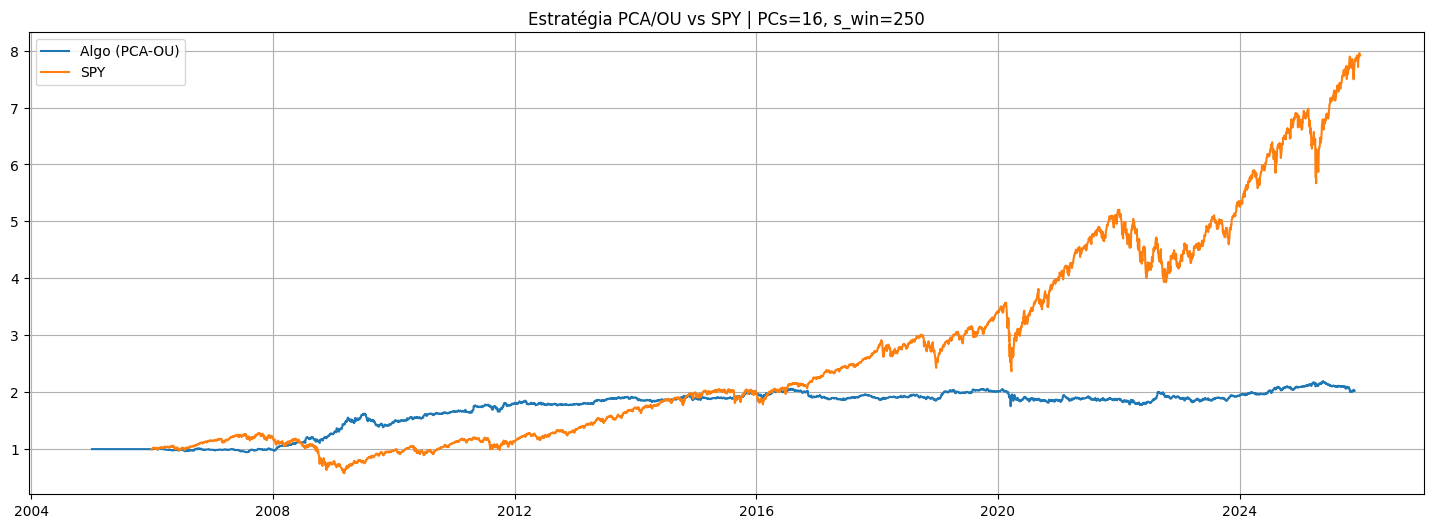

In [ ]:
returns_opt = returns_longa.loc["2003-01-01":"2025-12-31"]
bench_opt   = returns_spy_longa.loc["2003-01-01":"2025-12-31"]

res = pca_portfolio_adaptive_pcs(
    returns=returns_opt,
    returns_bench=bench_opt,
    benchmark="SPY",
    variance_target=0.70,
    min_pcs=5,
    max_pcs=35,
    s_win=int(best["s_win"]),
    ma_window=int(best["ma_window"]),
    window_pca=60,
    adaptive_thresholds=True,
    adaptive_window=60,
    percentile_open=float(best["percentile_open"]),
    percentile_close_short=float(best["percentile_close_short"]),
    percentile_close_long=float(best["percentile_close_long"]),
    eps_cost=0.0005,
    rebalanceamento_dias=int(best["rebalanceamento_dias"]),
    kappa_min=float(best["kappa_min"]),
    plot=True,
    use_drift=True,
    verbose=True
)

In [15]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_res = res_oos['ret_net']
stats_res = stats_from_returns(ret_res)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2025)")
print("="*70)
for k, v in stats_res.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")


PERFORMANCE DA ESTRATÉGIA (1999-2025)
  CAGR      :     0.0343 (   3.43%)
  Vol       :     0.0723 (   7.23%)
  Sharpe    :     0.4746 (  47.46%)
  MaxDD     :    -0.1492 ( -14.92%)



### Otimização usando walk-forward

In [ ]:
# --------------------------
# MÉTRICAS
# --------------------------
def sharpe_ann(r: pd.Series, trading_days: int = 252) -> float:
    r = r.dropna()
    if len(r) < 60:
        return np.nan
    vol = r.std(ddof=1)
    if vol == 0 or not np.isfinite(vol):
        return np.nan
    return float(np.sqrt(trading_days) * r.mean() / vol)

def score_strategy(ret_net: pd.Series, trading_days: int = 252) -> float:
    r = ret_net.dropna()
    if len(r) < 60:
        return -np.inf
    sh = sharpe_ann(r, trading_days=trading_days)
    if np.isnan(sh):
        return -np.inf
    return sh

def splits(index: pd.Index, *, n_folds: int = 3, window_size: int = 252*2, step_size: int | None = 252):
    n = len(index)
    if step_size is None:
        step_size = window_size // 2
        step_size = max(step_size, 1)

    out = []
    start = 0
    for _ in range(n_folds):
        end = start + window_size
        if end > n:
            break
        out.append((start, end))
        start += step_size
    return out

def eval_params_train_cv(
    returns_train: pd.DataFrame,
    bench_train: pd.Series | pd.DataFrame,
    params: dict,
    trial: optuna.Trial | None = None,
    *,
    n_folds: int = 3,
    window_size: int = 252*2,
    step_size: int | None = 252,
    min_points: int = 60,
) -> float:
    # alinhamento local (treino)
    common = returns_train.index.intersection(bench_train.index)
    returns_train = returns_train.loc[common]
    bench_train   = bench_train.loc[common]

    if len(returns_train) < window_size + min_points:
        return -np.inf

    fold_scores = []
    for k, (st, en) in enumerate(splits(returns_train.index, n_folds=n_folds, window_size=window_size, step_size=step_size)):
        R = returns_train.iloc[st:en]
        B = bench_train.iloc[st:en]

        try:
            res = pca_portfolio_hedge(
                returns=R,
                returns_bench=B,
                benchmark=params.get("benchmark", "BENCH"),
                num_pc=int(params["num_pc"]),
                s_win=int(params["s_win"]),
                sbo=float(params["sbo"]),
                sso=float(params["sso"]),
                sbc=float(params["sbc"]),
                ssc=float(params["ssc"]),
                eps_cost=float(params["eps_cost"]),
                rebalanceamento_dias=int(params["rebalanceamento_dias"]),
                kappa_min=float(params["kappa_min"]),
                plot=False,
                use_drift=bool(params["use_drift"]),
                ma_window=int(params["ma_window"]),
                verbose=False,
            )
        except Exception:
            return -np.inf

        ret_fold = res["ret_net"].reindex(R.index).dropna()
        if len(ret_fold) < min_points:
            return -np.inf

        fold_scores.append(score_strategy(ret_fold))

        if trial is not None:
            trial.report(float(np.mean(fold_scores)), step=k)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return float(np.mean(fold_scores)) if fold_scores else -np.inf

In [ ]:
def optimize_then_trade_yearly_with_gap(
    returns: pd.DataFrame,
    bench: pd.Series | pd.DataFrame,
    *,
    train_years: int = 4,
    gap_years: int = 1,
    start_test_year: int = 2005,
    end_test_year: int = 2025,
    reopt_every: int = 1,  # 1=anual, 2=a cada 2 anos, etc.
    n_trials: int = 60,
    n_folds: int = 3,
    cv_window_size: int = 252*2,
    cv_step_size: int = 252,
    seed: int = 42,
    storage: str = "sqlite:///optuna_yearly_eua.db",
    study_prefix: str = "wfo",
    params_ckpt_path: str = "params_eua_year.csv",
    rets_ckpt_path: str = "ret_oos_eua.csv",
):
    
    if reopt_every <= 0:
        raise ValueError("reopt_every must be >= 1")
    
    # alinhamento global
    common = returns.index.intersection(bench.index)
    returns = returns.loc[common]
    bench   = bench.loc[common]

    # --------- resume: carregar checkpoints se existirem
    if os.path.exists(params_ckpt_path):
        params_table = pd.read_csv(params_ckpt_path)
    else:
        params_table = pd.DataFrame()

    if os.path.exists(rets_ckpt_path):
        df_tmp = pd.read_csv(rets_ckpt_path, index_col=0, parse_dates=True)
        ret_oos_all = df_tmp["ret_oos"].sort_index()
    else:
        ret_oos_all = pd.Series(dtype=float, name="ret_oos")

    done_years = set(params_table["year_test"].tolist()) if not params_table.empty else set()

    def objective_factory(R_train, B_train):
        def objective(trial: optuna.Trial) -> float:
            s_win = trial.suggest_int("s_win", 60, 250, step=5)
            ma_window = trial.suggest_int("ma_window", 20, s_win - 2, step=2)

            sbo = trial.suggest_float("sbo", 0.8, 2.5)
            sso = trial.suggest_float("sso", 0.8, 2.5)
            sbc = trial.suggest_float("sbc", 0.1, sso - 0.05)
            ssc = trial.suggest_float("ssc", 0.1, sbo - 0.05)

            kappa_min = trial.suggest_float("kappa_min", 1.0, 20.0)
            num_pc = trial.suggest_int("num_pc", 5, 20)
            rebalanceamento_dias = trial.suggest_int("rebalanceamento_dias", 1, 30)

            params = dict(
                benchmark="IBOV",
                num_pc=num_pc,
                s_win=s_win,
                ma_window=ma_window,
                sbo=sbo, sso=sso, sbc=sbc, ssc=ssc,
                eps_cost=0.0005,
                rebalanceamento_dias=rebalanceamento_dias,
                kappa_min=kappa_min,
                use_drift=True,
            )

            return eval_params_train_cv(
                R_train, B_train, params, trial=trial,
                n_folds=n_folds,
                window_size=cv_window_size,
                step_size=cv_step_size,
            )
        return objective

    # -------------------------
    # Estado: params correntes (para reuso entre anos)
    # -------------------------
    current_params: dict | None = None
    current_score: float | None = None
    last_opt_year: int | None = None

    # janela usada quando otimizou (pra warmup consistente nos anos reusados)
    last_train_start: int | None = None
    last_train_end: int | None = None
    last_gap_year: int | None = None

    # Se você está retomando e quer reusar params do último ano já feito:
    if not params_table.empty:
        last_done = int(params_table["year_test"].max())
        # pega a última linha (ano mais recente) e usa como "current"
        row_last = params_table.loc[params_table["year_test"] == last_done].iloc[-1]
        # só tenta se as colunas existirem (primeiras execuções antigas talvez não tenham)
        needed_cols = ["num_pc", "s_win", "ma_window", "sbo", "sso", "sbc", "ssc", "rebalanceamento_dias", "kappa_min"]
        if all(c in params_table.columns for c in needed_cols):
            current_params = dict(
                benchmark=str(row_last.get("benchmark", "IBOV")),
                num_pc=int(row_last["num_pc"]),
                s_win=int(row_last["s_win"]),
                ma_window=int(row_last["ma_window"]),
                sbo=float(row_last["sbo"]),
                sso=float(row_last["sso"]),
                sbc=float(row_last["sbc"]),
                ssc=float(row_last["ssc"]),
                eps_cost=float(row_last.get("eps_cost", 0.0005)),
                rebalanceamento_dias=int(row_last["rebalanceamento_dias"]),
                kappa_min=float(row_last["kappa_min"]),
                use_drift=bool(row_last.get("use_drift", True)),
            )
            current_score = float(row_last.get("cv_score_train", np.nan))
            last_opt_year = int(row_last.get("opt_year", row_last["year_test"]))
            last_train_start = int(row_last.get("train_start_year", np.nan)) if "train_start_year" in row_last else None
            last_train_end   = int(row_last.get("train_end_year", np.nan)) if "train_end_year" in row_last else None
            last_gap_year    = int(row_last.get("gap_year", np.nan)) if "gap_year" in row_last else None


    for y in range(start_test_year, end_test_year + 1):
        if y in done_years:
            continue

        train_start = y - gap_years - train_years
        train_end   = y - gap_years - 1
        gap_year    = y - 1
        test_year   = y

        R_train = returns.loc[(returns.index.year >= train_start) & (returns.index.year <= train_end)]
        B_train = bench.loc[(bench.index.year >= train_start) & (bench.index.year <= train_end)]
        R_test  = returns.loc[(returns.index.year == test_year)]
        B_test  = bench.loc[(bench.index.year == test_year)]

        if len(R_train) < 252 * 3 or len(R_test) < 60:
            continue

        # Reotimiza?
        # - primeiro ano sempre
        # - depois a cada reopt_every anos
        need_opt = (current_params is None) or (((y - start_test_year) % reopt_every) == 0)

        if need_opt:
            sampler = optuna.samplers.TPESampler(seed=seed + (y - start_test_year))
            pruner  = optuna.pruners.HyperbandPruner(min_resource=1, max_resource=n_folds, reduction_factor=3)

            study = optuna.create_study(
                direction="maximize",
                sampler=sampler,
                pruner=pruner,
                study_name=f"{study_prefix}_{y}",
                storage=storage,
                load_if_exists=True,
            )

            remaining = n_trials - len(study.trials)
            if remaining > 0:
                study.optimize(objective_factory(R_train, B_train), n_trials=remaining, n_jobs=1, show_progress_bar=False)

            bp = study.best_params
            current_params = dict(
                benchmark="IBOV",
                num_pc=int(bp["num_pc"]),
                s_win=int(bp["s_win"]),
                ma_window=int(bp["ma_window"]),
                sbo=float(bp["sbo"]),
                sso=float(bp["sso"]),
                sbc=float(bp["sbc"]),
                ssc=float(bp["ssc"]),
                eps_cost=0.0005,
                rebalanceamento_dias=int(bp["rebalanceamento_dias"]),
                kappa_min=float(bp["kappa_min"]),
                use_drift=True,
            )
            current_score = float(study.best_value)
            last_opt_year = y
            last_train_start, last_train_end, last_gap_year = train_start, train_end, gap_year

        # Segurança (não deve acontecer)
        if current_params is None or last_train_start is None:
            raise RuntimeError("Estado inválido: current_params/last_train_start não definido.")

        # Execução com warmup consistente: começa no treino do último opt
        R_exec = returns.loc[(returns.index.year >= last_train_start) & (returns.index.year <= test_year)]
        B_exec = bench.loc[(bench.index.year >= last_train_start) & (bench.index.year <= test_year)]
        test_idx = returns.loc[returns.index.year == test_year].index

        print(f"\n=== Test Year: {test_year} | Train: {last_train_start}-{last_train_end} | Gap: {last_gap_year} | Opt: {last_opt_year} | Score (train CV): {current_score:.4f} ===")
        res_exec = pca_portfolio_hedge(
            returns=R_exec,
            returns_bench=B_exec,
            benchmark=current_params["benchmark"],
            num_pc=current_params["num_pc"],
            s_win=current_params["s_win"],
            sbo=current_params["sbo"],
            sso=current_params["sso"],
            sbc=current_params["sbc"],
            ssc=current_params["ssc"],
            eps_cost=current_params["eps_cost"],
            rebalanceamento_dias=current_params["rebalanceamento_dias"],
            kappa_min=current_params["kappa_min"],
            plot=False,
            use_drift=current_params["use_drift"],
            ma_window=current_params["ma_window"],
            verbose=False,
        )

        print(f"Test Year {test_year} - Score OOS: {score_strategy(res_exec['ret_net'].reindex(test_idx).dropna()):.4f}")
        ret_y = res_exec["ret_net"].reindex(test_idx).dropna()
        if len(ret_y) < 60:
            continue

        if ret_oos_all.empty:
            ret_oos_all = ret_y.sort_index()
        else:
            ret_oos_all = pd.concat([ret_oos_all, ret_y]).sort_index()
        ret_oos_all.name = "ret_oos"

        row = {
            "year_test": test_year,
            "train_start_year": last_train_start,
            "train_end_year": last_train_end,
            "gap_year": last_gap_year,
            "opt_year": last_opt_year,
            "cv_score_train": current_score,
            **current_params,
        }

        new_row_df = pd.DataFrame([row])
        if params_table.empty:
            params_table = new_row_df
        else:
            params_table = pd.concat([params_table, new_row_df], ignore_index=True)
        params_table = params_table.sort_values("year_test").reset_index(drop=True)

        print(f"Parameters for test year {test_year} saved. OOS return for the year: {ret_y.sum():.4f}")
        # checkpoints
        params_table.to_csv(params_ckpt_path, index=False)
        ret_oos_all.to_frame("ret_oos").to_csv(rets_ckpt_path)

    if ret_oos_all.empty:
        raise RuntimeError("Nenhum ano OOS gerado (verifique anos/índices).")

    cum_oos = (1.0 + ret_oos_all).cumprod()
    return {"ret_oos": ret_oos_all, "cum_oos": cum_oos, "params_table": params_table}

In [11]:
out = optimize_then_trade_yearly_with_gap(
    returns=returns_longa,
    bench=returns_spy_longa,
    train_years=4,
    gap_years=1,
    start_test_year=2002,
    end_test_year=2025,
    reopt_every=4,
    n_trials=60,
    n_folds=3,
    cv_window_size=252*2,
    cv_step_size=252,
    seed=42,
)

[I 2026-03-01 23:08:10,907] A new study created in RDB with name: wfo_2002
[I 2026-03-01 23:27:50,508] Trial 0 finished with value: 0.6785647387210787 and parameters: {'s_win': 130, 'ma_window': 124, 'sbo': 2.044389701079389, 'sso': 1.8177194231349623, 'sbc': 0.3601953170369613, 'ssc': 0.39551441274972154, 'kappa_min': 2.1035886311957896, 'num_pc': 11, 'rebalanceamento_dias': 19}. Best is trial 0 with value: 0.6785647387210787.
d:\savio\Python\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [20, 193] and step=2, but the range is not divisible by `step`. It will be replaced with [20, 192].
  optuna_warn(
[I 2026-03-01 23:45:01,301] Trial 1 finished with value: 0.003724261729259363 and parameters: {'s_win': 195, 'ma_window': 22, 'sbo': 2.4488467486753906, 'sso': 2.215152489360717, 'sbc': 0.5385126430058829, 'ssc': 0.5179877346920528, 'kappa_min': 4.484685687215243, 'num_pc': 4, 'rebalanceamento_dias': 16}. Best is trial 0 with value: 0.6785647


=== Test Year: 2002 | Train: 1997-2000 | Gap: 2001 | Opt: 2002 | Score (train CV): 1.2286 ===
Test Year 2002 - Score OOS: 2.9304
Parameters for test year 2002 saved. OOS return for the year: 0.3570

=== Test Year: 2003 | Train: 1997-2000 | Gap: 2001 | Opt: 2002 | Score (train CV): 1.2286 ===
Test Year 2003 - Score OOS: 1.8353
Parameters for test year 2003 saved. OOS return for the year: 0.1364

=== Test Year: 2004 | Train: 1997-2000 | Gap: 2001 | Opt: 2002 | Score (train CV): 1.2286 ===
Test Year 2004 - Score OOS: 0.6280
Parameters for test year 2004 saved. OOS return for the year: 0.0348

=== Test Year: 2005 | Train: 1997-2000 | Gap: 2001 | Opt: 2002 | Score (train CV): 1.2286 ===
Test Year 2005 - Score OOS: 0.1174
Parameters for test year 2005 saved. OOS return for the year: 0.0044


[I 2026-03-02 16:25:31,302] A new study created in RDB with name: wfo_2006
[I 2026-03-02 16:37:45,498] Trial 0 finished with value: 1.0863962029423728 and parameters: {'s_win': 210, 'ma_window': 140, 'sbo': 1.2233732555767731, 'sso': 2.08872896990469, 'sbc': 0.7069713249181235, 'ssc': 1.1060055136554932, 'kappa_min': 1.8144435186930143, 'num_pc': 6, 'rebalanceamento_dias': 28}. Best is trial 0 with value: 1.0863962029423728.
d:\savio\Python\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [20, 143] and step=2, but the range is not divisible by `step`. It will be replaced with [20, 142].
  optuna_warn(
[I 2026-03-02 16:52:26,659] Trial 1 pruned. 
d:\savio\Python\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [20, 133] and step=2, but the range is not divisible by `step`. It will be replaced with [20, 132].
  optuna_warn(
[I 2026-03-02 17:08:05,350] Trial 2 finished with value: 1.26948726044747 and 


=== Test Year: 2006 | Train: 2001-2004 | Gap: 2005 | Opt: 2006 | Score (train CV): 2.2854 ===
Test Year 2006 - Score OOS: 0.1583
Parameters for test year 2006 saved. OOS return for the year: 0.0072

=== Test Year: 2007 | Train: 2001-2004 | Gap: 2005 | Opt: 2006 | Score (train CV): 2.2854 ===
Test Year 2007 - Score OOS: 0.3224
Parameters for test year 2007 saved. OOS return for the year: 0.0149

=== Test Year: 2008 | Train: 2001-2004 | Gap: 2005 | Opt: 2006 | Score (train CV): 2.2854 ===
Test Year 2008 - Score OOS: 0.5472
Parameters for test year 2008 saved. OOS return for the year: 0.0597

=== Test Year: 2009 | Train: 2001-2004 | Gap: 2005 | Opt: 2006 | Score (train CV): 2.2854 ===
Test Year 2009 - Score OOS: -0.3009
Parameters for test year 2009 saved. OOS return for the year: -0.0503


[I 2026-03-03 06:46:30,255] A new study created in RDB with name: wfo_2010
d:\savio\Python\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [20, 153] and step=2, but the range is not divisible by `step`. It will be replaced with [20, 152].
  optuna_warn(
[I 2026-03-03 06:56:12,242] Trial 0 finished with value: -0.23391008621322434 and parameters: {'s_win': 155, 'ma_window': 50, 'sbo': 1.2343056703872592, 'sso': 1.4737608465287209, 'sbc': 0.5994749531276693, 'ssc': 1.1805910887185038, 'kappa_min': 8.755746806330745, 'num_pc': 10, 'rebalanceamento_dias': 23}. Best is trial 0 with value: -0.23391008621322434.
[I 2026-03-03 07:06:33,630] Trial 1 pruned. 
[I 2026-03-03 07:14:51,470] Trial 2 finished with value: -0.1999190190080983 and parameters: {'s_win': 190, 'ma_window': 86, 'sbo': 1.66221301065206, 'sso': 1.6909759545289937, 'sbc': 1.5300271155459035, 'ssc': 0.9640377889368624, 'kappa_min': 13.698413806756921, 'num_pc': 1, 'rebalanceamento_dia

...

Test Year 2017 - Score OOS: -0.9487
Parameters for test year 2017 saved. OOS return for the year: -0.0451


[I 2026-03-04 10:28:51,647] Trial 0 finished with value: -0.9554669415446216 and parameters: {'s_win': 130, 'ma_window': 68, 'sbo': 1.643302592905242, 'sso': 0.9285575132117329, 'sbc': 0.5451492756870758, 'ssc': 0.5325112118157842, 'kappa_min': 6.867284716980071, 'num_pc': 5, 'rebalanceamento_dias': 25}. Best is trial 0 with value: -0.9554669415446216.
d:\savio\Python\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [20, 243] and step=2, but the range is not divisible by `step`. It will be replaced with [20, 242].
  optuna_warn(
[I 2026-03-04 10:43:16,336] Trial 1 finished with value: 0.38159637183778955 and parameters: {'s_win': 245, 'ma_window': 196, 'sbo': 1.4471591061603966, 'sso': 1.0766175677742869, 'sbc': 0.6072190376414457, 'ssc': 1.111707153933703, 'kappa_min': 6.700830427937873, 'num_pc': 8, 'rebalanceamento_dias': 9}. Best is trial 1 with value: 0.38159637183778955.
d:\savio\Python\Lib\site-packages\optuna\distributions.py:684: Use


=== Test Year: 2018 | Train: 2013-2016 | Gap: 2017 | Opt: 2018 | Score (train CV): 1.1004 ===
Test Year 2018 - Score OOS: 0.9541
Parameters for test year 2018 saved. OOS return for the year: 0.0925

=== Test Year: 2019 | Train: 2013-2016 | Gap: 2017 | Opt: 2018 | Score (train CV): 1.1004 ===
Test Year 2019 - Score OOS: 1.5760
Parameters for test year 2019 saved. OOS return for the year: 0.1950

=== Test Year: 2020 | Train: 2013-2016 | Gap: 2017 | Opt: 2018 | Score (train CV): 1.1004 ===
Test Year 2020 - Score OOS: -0.0657
Parameters for test year 2020 saved. OOS return for the year: -0.0129

=== Test Year: 2021 | Train: 2013-2016 | Gap: 2017 | Opt: 2018 | Score (train CV): 1.1004 ===
Test Year 2021 - Score OOS: 1.0595
Parameters for test year 2021 saved. OOS return for the year: 0.0967


[I 2026-03-05 04:03:05,807] A new study created in RDB with name: wfo_2022
d:\savio\Python\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [20, 63] and step=2, but the range is not divisible by `step`. It will be replaced with [20, 62].
  optuna_warn(
[I 2026-03-05 04:17:36,611] Trial 0 finished with value: 0.36402305678770575 and parameters: {'s_win': 65, 'ma_window': 40, 'sbo': 2.238344665377501, 'sso': 1.4993833996766166, 'sbc': 0.9520214236129007, 'ssc': 0.7075897574723916, 'kappa_min': 11.313205489673978, 'num_pc': 3, 'rebalanceamento_dias': 8}. Best is trial 0 with value: 0.36402305678770575.
d:\savio\Python\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [20, 243] and step=2, but the range is not divisible by `step`. It will be replaced with [20, 242].
  optuna_warn(
[I 2026-03-05 04:26:55,358] Trial 1 finished with value: 0.6058581660962377 and parameters: {'s_win': 245, 'ma_window': 164, 


=== Test Year: 2022 | Train: 2017-2020 | Gap: 2021 | Opt: 2022 | Score (train CV): 1.8725 ===
Test Year 2022 - Score OOS: 0.8549
Parameters for test year 2022 saved. OOS return for the year: 0.1313

=== Test Year: 2023 | Train: 2017-2020 | Gap: 2021 | Opt: 2022 | Score (train CV): 1.8725 ===
Test Year 2023 - Score OOS: -1.3574
Parameters for test year 2023 saved. OOS return for the year: -0.1410

=== Test Year: 2024 | Train: 2017-2020 | Gap: 2021 | Opt: 2022 | Score (train CV): 1.8725 ===
Test Year 2024 - Score OOS: 0.3518
Parameters for test year 2024 saved. OOS return for the year: 0.0372

=== Test Year: 2025 | Train: 2017-2020 | Gap: 2021 | Opt: 2022 | Score (train CV): 1.8725 ===
Test Year 2025 - Score OOS: 0.3784
Parameters for test year 2025 saved. OOS return for the year: 0.0546


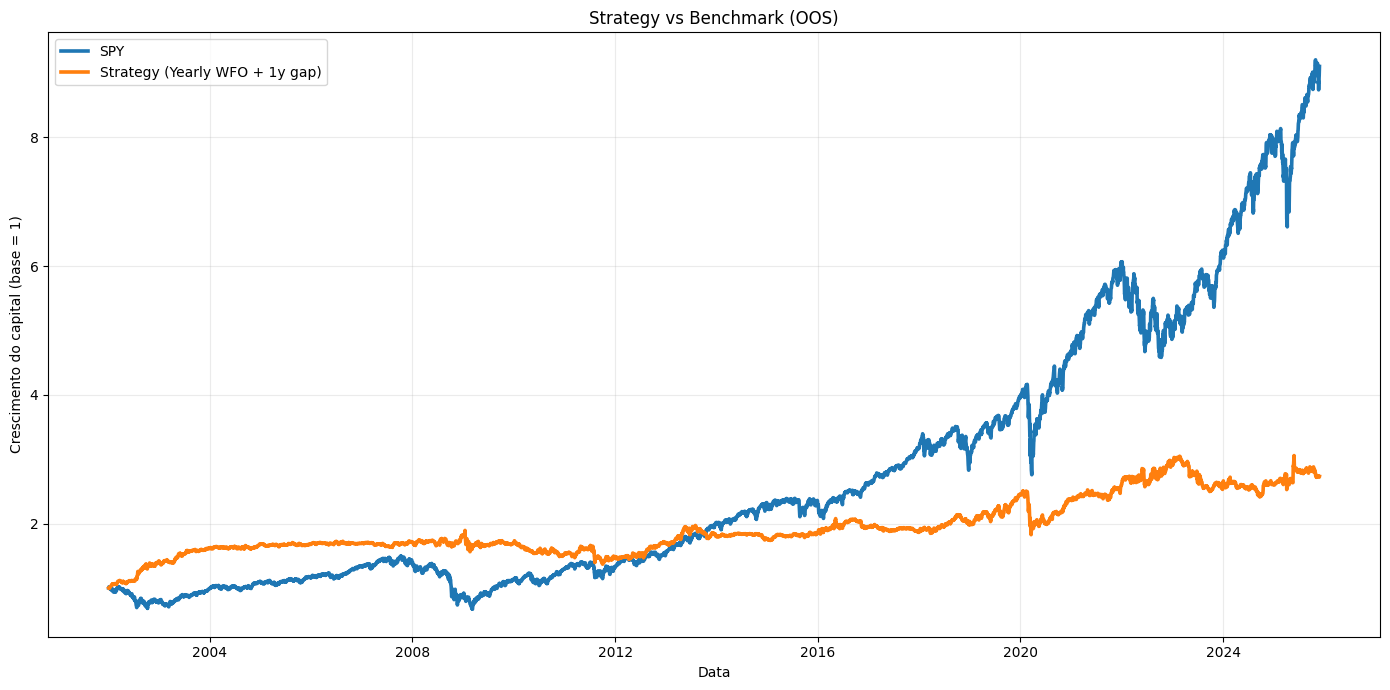

In [13]:
ret_oos = out["ret_oos"]
cum_oos = out["cum_oos"]
params_table = out["params_table"]

# Benchmark no mesmo período OOS
bench_oos = (returns_spy_longa if isinstance(returns_spy_longa, pd.Series) else returns_spy_longa.iloc[:,0])
bench_oos = bench_oos.reindex(ret_oos.index).dropna()

common = ret_oos.index.intersection(bench_oos.index)
ret_oos = ret_oos.loc[common]
bench_oos = bench_oos.loc[common]

cum_strat = (1 + ret_oos).cumprod()
cum_bench = (1 + bench_oos).cumprod()

# normaliza início
cum_strat = cum_strat / cum_strat.iloc[0]
cum_bench = cum_bench / cum_bench.iloc[0]

plt.figure(figsize=(14,7))
plt.plot(cum_bench.index, cum_bench, linewidth=2.6, label="SPY")
plt.plot(cum_strat.index, cum_strat, linewidth=2.6, label="Strategy (Yearly WFO + 1y gap)")
plt.grid(alpha=0.25)
plt.title("Strategy vs Benchmark (OOS)")
plt.xlabel("Data")
plt.ylabel("Crescimento do capital (base = 1)")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# =============================================================================
# ESTATÍSTICAS BÁSICAS
# =============================================================================

stats_res = stats_from_returns(ret_oos)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (2002-2025)")
print("="*70)
for k, v in stats_res.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")


PERFORMANCE DA ESTRATÉGIA (2002-2025)
  CAGR      :     0.0430 (   4.30%)
  Vol       :     0.1100 (  11.00%)
  Sharpe    :     0.3910 (  39.10%)
  MaxDD     :    -0.2770 ( -27.70%)



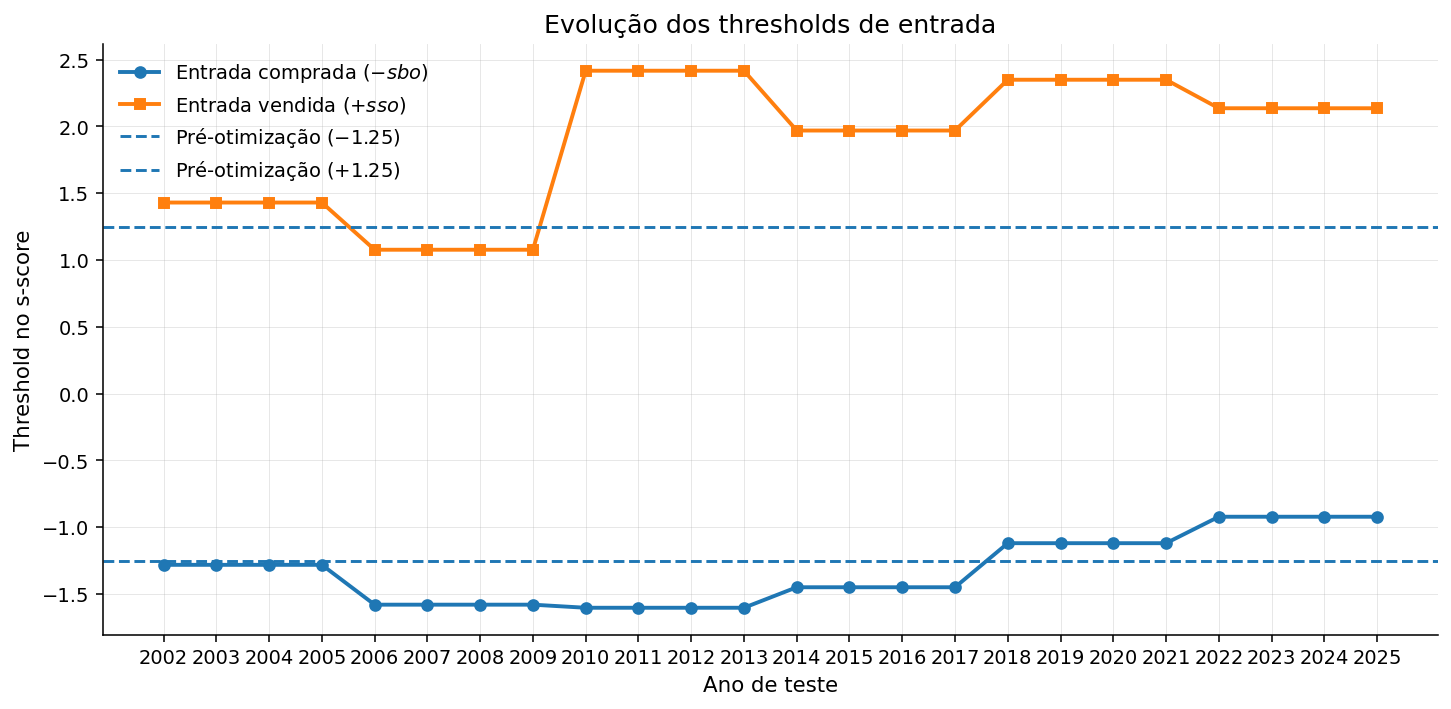

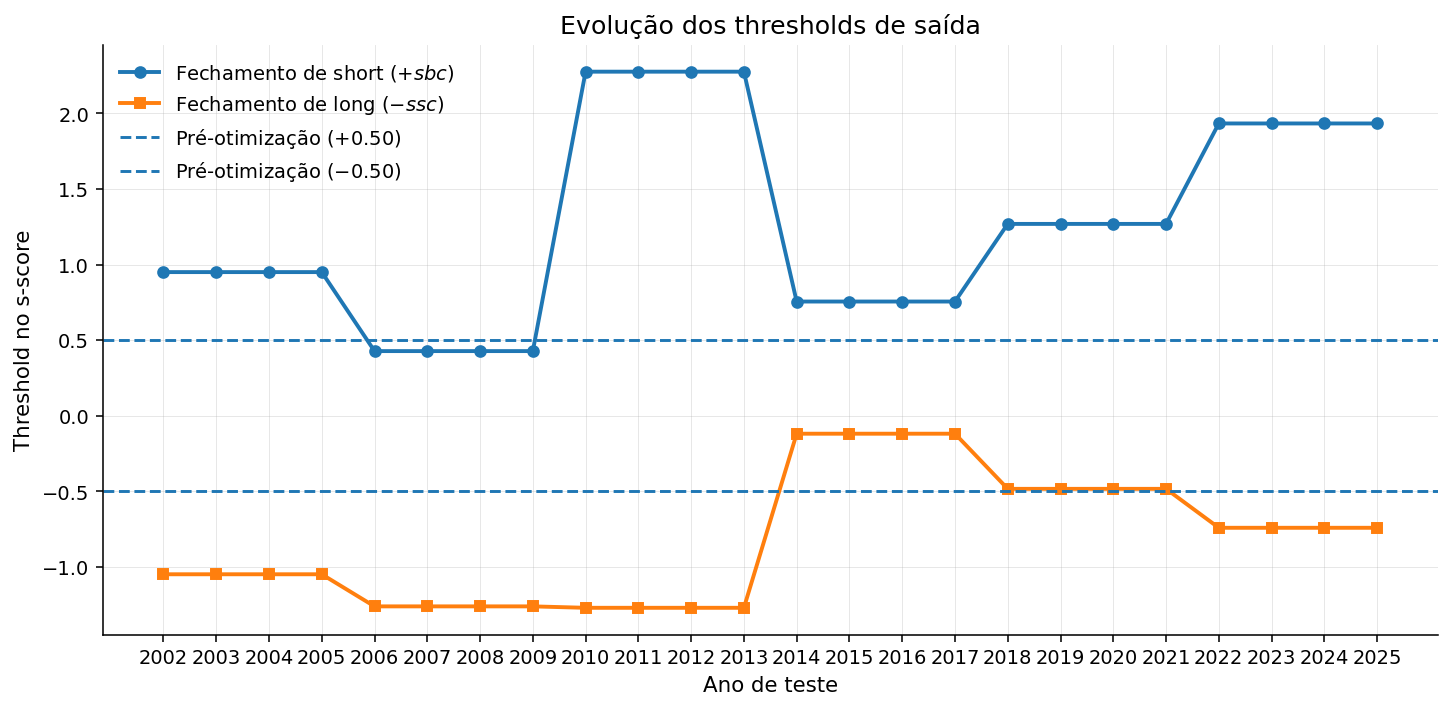

In [17]:
df = pd.read_csv("params_eua_year.csv")
df = df.sort_values("year_test").copy()

# Aplicar os sinais reais usados na estratégia
df["entry_long"]  = -df["sbo"]   # buy-to-open:  s < -sbo
df["entry_short"] =  df["sso"]   # sell-to-open: s > +sso
df["exit_short"]  =  df["sbc"]   # close short:  s < +sbc
df["exit_long"]   = -df["ssc"]   # close long:   s > -ssc

years = df["year_test"]

# Thresholds antigos (pré-otimização)
OLD_ENTRY_LONG  = -1.25
OLD_ENTRY_SHORT =  1.25
OLD_EXIT_SHORT  =  0.50
OLD_EXIT_LONG   = -0.50


plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "lines.linewidth": 2.0,
    "lines.markersize": 5.5,
})

# =========================
# 3) Gráfico 1: Entradas
# =========================
fig, ax = plt.subplots(figsize=(10.5, 5.2))

ax.plot(
    years, df["entry_long"],
    marker="o",
    label=r"Entrada comprada $(-sbo)$"
)

ax.plot(
    years, df["entry_short"],
    marker="s",
    label=r"Entrada vendida $(+sso)$"
)

# Linhas antigas
ax.axhline(
    OLD_ENTRY_LONG, linestyle="--", linewidth=1.5,
    label=r"Pré-otimização $(-1.25)$"
)
ax.axhline(
    OLD_ENTRY_SHORT, linestyle="--", linewidth=1.5,
    label=r"Pré-otimização $(+1.25)$"
)

ax.set_title("Evolução dos thresholds de entrada")
ax.set_xlabel("Ano de teste")
ax.set_ylabel("Threshold no s-score")
ax.set_xticks(years)
ax.grid(True, alpha=0.30)
ax.legend(loc="best", frameon=False)

plt.tight_layout()
plt.savefig("thresholds_entrada_paper.pdf", bbox_inches="tight")
plt.show()

# =========================
# 4) Gráfico 2: Saídas
# =========================
fig, ax = plt.subplots(figsize=(10.5, 5.2))

ax.plot(
    years, df["exit_short"],
    marker="o",
    label=r"Fechamento de short $(+sbc)$"
)

ax.plot(
    years, df["exit_long"],
    marker="s",
    label=r"Fechamento de long $(-ssc)$"
)

# Linhas antigas
ax.axhline(
    OLD_EXIT_SHORT, linestyle="--", linewidth=1.5,
    label=r"Pré-otimização $(+0.50)$"
)
ax.axhline(
    OLD_EXIT_LONG, linestyle="--", linewidth=1.5,
    label=r"Pré-otimização $(-0.50)$"
)

ax.set_title("Evolução dos thresholds de saída")
ax.set_xlabel("Ano de teste")
ax.set_ylabel("Threshold no s-score")
ax.set_xticks(years)
ax.grid(True, alpha=0.30)
ax.legend(loc="best", frameon=False)

plt.tight_layout()
plt.savefig("thresholds_saida_paper.pdf", bbox_inches="tight")
plt.show()

### Atualizando com base o s-score do treino

In [ ]:
# --------------------------
# MÉTRICAS
# --------------------------
def sharpe_ann(r: pd.Series, trading_days: int = 252) -> float:
    r = r.dropna()
    if len(r) < 60:
        return np.nan
    vol = r.std(ddof=1)
    if vol == 0 or not np.isfinite(vol):
        return np.nan
    return float(np.sqrt(trading_days) * r.mean() / vol)

def score_strategy(ret_net: pd.Series, trading_days: int = 252) -> float:
    r = ret_net.dropna()
    if len(r) < 60:
        return -np.inf
    sh = sharpe_ann(r, trading_days=trading_days)
    if np.isnan(sh):
        return -np.inf
    return sh

def splits(index: pd.Index, *, n_folds: int = 3, window_size: int = 252*2, step_size: int | None = 252):
    n = len(index)
    if step_size is None:
        step_size = window_size // 2
        step_size = max(step_size, 1)

    out = []
    start = 0
    for _ in range(n_folds):
        end = start + window_size
        if end > n:
            break
        out.append((start, end))
        start += step_size
    return out

def eval_params_train_cv(
    returns_train: pd.DataFrame,
    bench_train: pd.Series | pd.DataFrame,
    params: dict,
    trial: optuna.Trial | None = None,
    *,
    n_folds: int = 3,
    window_size: int = 252*2,
    step_size: int | None = 252,
    min_points: int = 60,
) -> float:
    # alinhamento local (treino)
    common = returns_train.index.intersection(bench_train.index)
    returns_train = returns_train.loc[common]
    bench_train   = bench_train.loc[common]

    if len(returns_train) < window_size + min_points:
        return -np.inf

    fold_scores = []
    for k, (st, en) in enumerate(splits(returns_train.index, n_folds=n_folds, window_size=window_size, step_size=step_size)):
        R = returns_train.iloc[st:en]
        B = bench_train.iloc[st:en]

        try:
            res = pca_portfolio_hedge(
                returns=R,
                returns_bench=B,
                benchmark=params.get("benchmark", "BENCH"),
                num_pc=int(params["num_pc"]),
                s_win=int(params["s_win"]),
                sbo=float(params["sbo"]),
                sso=float(params["sso"]),
                sbc=float(params["sbc"]),
                ssc=float(params["ssc"]),
                eps_cost=float(params["eps_cost"]),
                rebalanceamento_dias=int(params["rebalanceamento_dias"]),
                kappa_min=float(params["kappa_min"]),
                plot=False,
                use_drift=bool(params["use_drift"]),
                ma_window=int(params["ma_window"]),
                verbose=False,
            )
        except Exception:
            return -np.inf

        ret_fold = res["ret_net"].reindex(R.index).dropna()
        if len(ret_fold) < min_points:
            return -np.inf

        fold_scores.append(score_strategy(ret_fold))

        if trial is not None:
            trial.report(float(np.mean(fold_scores)), step=k)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return float(np.mean(fold_scores)) if fold_scores else -np.inf

In [ ]:
def optimize_params(
    returns: pd.DataFrame,
    bench: pd.Series | pd.DataFrame,
    *,
    train_years: int = 4,
    gap_years: int = 1,
    start_test_year: int = 2005,
    end_test_year: int = 2025,
    reopt_every: int = 1,  # 1=anual, 2=a cada 2 anos, etc.
    n_trials: int = 60,
    n_folds: int = 3,
    cv_window_size: int = 252*2,
    cv_step_size: int = 252,
    seed: int = 42,
    storage: str = "sqlite:///optuna_yearly_usa_new.db",
    study_prefix: str = "wfo",
    params_ckpt_path: str = "params_by_year_usa_new.csv",
    rets_ckpt_path: str = "ret_oos_usa_new.csv",
):
    
    if reopt_every <= 0:
        raise ValueError("reopt_every must be >= 1")
    
    # alinhamento global
    common = returns.index.intersection(bench.index)
    returns = returns.loc[common]
    bench   = bench.loc[common]

    # --------- resume: carregar checkpoints se existirem
    if os.path.exists(params_ckpt_path):
        params_table = pd.read_csv(params_ckpt_path)
    else:
        params_table = pd.DataFrame()

    if os.path.exists(rets_ckpt_path):
        df_tmp = pd.read_csv(rets_ckpt_path, index_col=0, parse_dates=True)
        ret_oos_all = df_tmp["ret_oos"].sort_index()
    else:
        ret_oos_all = pd.Series(dtype=float, name="ret_oos")

    done_years = set(params_table["year_test"].tolist()) if not params_table.empty else set()

    def objective_factory(R_train, B_train):
        def objective(trial: optuna.Trial) -> float:
            s_win = trial.suggest_int("s_win", 30, 200, step=5)
            ma_window = trial.suggest_int("ma_window", 20, s_win - 2, step=2)

            sbo = trial.suggest_float("sbo", 0.8, 2.5)
            sso = trial.suggest_float("sso", 0.8, 2.5)
            sbc = trial.suggest_float("sbc", 0.1, sso - 0.05)
            ssc = trial.suggest_float("ssc", 0.1, sbo - 0.05)
            
            num_pc = trial.suggest_int("num_pc", 5, 20)
            rebalanceamento_dias = trial.suggest_int("rebalanceamento_dias", 1, 60)
            kappa_min = trial.suggest_float("kappa_min", 1.0, 20.0)


            params = dict(
                benchmark="IBOV",
                num_pc=num_pc,
                s_win=s_win,
                ma_window=ma_window,
                sbo=sbo, sso=sso, sbc=sbc, ssc=ssc,
                eps_cost=0.0005,
                rebalanceamento_dias=rebalanceamento_dias,
                kappa_min=kappa_min,
                use_drift=True,
            )

            return eval_params_train_cv(
                R_train, B_train, params, trial=trial,
                n_folds=n_folds,
                window_size=cv_window_size,
                step_size=cv_step_size,
            )
        return objective

    # -------------------------
    # Estado: params correntes (para reuso entre anos)
    # -------------------------
    current_params: dict | None = None
    current_score: float | None = None
    last_opt_year: int | None = None

    # janela usada quando otimizou (pra warmup consistente nos anos reusados)
    last_train_start: int | None = None
    last_train_end: int | None = None
    last_gap_year: int | None = None

    # Se você está retomando e quer reusar params do último ano já feito:
    if not params_table.empty:
        last_done = int(params_table["year_test"].max())
        # pega a última linha (ano mais recente) e usa como "current"
        row_last = params_table.loc[params_table["year_test"] == last_done].iloc[-1]
        # só tenta se as colunas existirem (primeiras execuções antigas talvez não tenham)
        needed_cols = ["num_pc", "s_win", "ma_window", "sbo", "sso", "sbc", "ssc", "rebalanceamento_dias", "kappa_min"]
        if all(c in params_table.columns for c in needed_cols):
            current_params = dict(
                benchmark=str(row_last.get("benchmark", "IBOV")),
                num_pc=int(row_last["num_pc"]),
                s_win=int(row_last["s_win"]),
                ma_window=int(row_last["ma_window"]),
                sbo=float(row_last["sbo"]),
                sso=float(row_last["sso"]),
                sbc=float(row_last["sbc"]),
                ssc=float(row_last["ssc"]),
                eps_cost=float(row_last.get("eps_cost", 0.0005)),
                rebalanceamento_dias=int(row_last["rebalanceamento_dias"]),
                kappa_min=float(row_last["kappa_min"]),
                use_drift=bool(row_last.get("use_drift", True)),
            )
            current_score = float(row_last.get("cv_score_train", np.nan))
            last_opt_year = int(row_last.get("opt_year", row_last["year_test"]))
            last_train_start = int(row_last.get("train_start_year", np.nan)) if "train_start_year" in row_last else None
            last_train_end   = int(row_last.get("train_end_year", np.nan)) if "train_end_year" in row_last else None
            last_gap_year    = int(row_last.get("gap_year", np.nan)) if "gap_year" in row_last else None


    for y in range(start_test_year, end_test_year + 1):
        if y in done_years:
            continue

        train_start = y - gap_years - train_years
        train_end   = y - gap_years - 1
        gap_year    = y - 1
        test_year   = y

        R_train = returns.loc[(returns.index.year >= train_start) & (returns.index.year <= train_end)]
        B_train = bench.loc[(bench.index.year >= train_start) & (bench.index.year <= train_end)]
        R_test  = returns.loc[(returns.index.year == test_year)]
        B_test  = bench.loc[(bench.index.year == test_year)]

        if len(R_train) < 252 or len(R_test) < 60:
            continue

        # Reotimiza?
        # - primeiro ano sempre
        # - depois a cada reopt_every anos
        need_opt = (current_params is None) or (((y - start_test_year) % reopt_every) == 0)

        if need_opt:
            sampler = optuna.samplers.TPESampler(seed=seed + (y - start_test_year))
            pruner  = optuna.pruners.HyperbandPruner(min_resource=1, max_resource=n_folds, reduction_factor=3)

            study = optuna.create_study(
                direction="maximize",
                sampler=sampler,
                pruner=pruner,
                study_name=f"{study_prefix}_{y}",
                storage=storage,
                load_if_exists=True,
            )

            remaining = n_trials - len(study.trials)
            if remaining > 0:
                study.optimize(objective_factory(R_train, B_train), n_trials=remaining, n_jobs=1, show_progress_bar=False)
            
            best_score = float(study.best_value)
            bp = study.best_params
            # -------------------------------
            # só atualiza se score > 1.7
            # -------------------------------

            threshold = 1.7

            accept = False
            if current_params is None:
                # primeira vez: precisa aceitar
                accept = True
            else:
                # aceita apenas se passar o threshold
                if best_score > threshold:
                    accept = True

            if accept:
                current_params = dict(
                    benchmark="IBOV",
                    num_pc=int(bp["num_pc"]),
                    s_win=int(bp["s_win"]),
                    ma_window=int(bp["ma_window"]),
                    sbo=float(bp["sbo"]),
                    sso=float(bp["sso"]),
                    sbc=float(bp["sbc"]),
                    ssc=float(bp["ssc"]),
                    eps_cost=0.0005,
                    rebalanceamento_dias=int(bp["rebalanceamento_dias"]),
                    kappa_min=float(bp["kappa_min"]),
                    use_drift=True,
                )

                last_opt_year = y
                last_train_start, last_train_end, last_gap_year = train_start, train_end, gap_year
                current_score = best_score
                print(f"[OPT ACCEPTED] year={y} best_score={best_score:.4f} (> {threshold})")
            else:
                print(f"[OPT REJECTED] year={y} best_score={best_score:.4f} (<= {threshold}). Keeping previous params.")

        # Segurança (não deve acontecer)
        if current_params is None or last_train_start is None:
            raise RuntimeError("Estado inválido: current_params/last_train_start não definido.")

        # Execução com warmup consistente: começa no treino do último opt
        R_exec = returns.loc[(returns.index.year >= last_train_start) & (returns.index.year <= test_year)]
        B_exec = bench.loc[(bench.index.year >= last_train_start) & (bench.index.year <= test_year)]
        test_idx = returns.loc[returns.index.year == test_year].index

        print(f"\n=== Test Year: {test_year} | Train: {last_train_start}-{last_train_end} | Gap: {last_gap_year} | Opt: {last_opt_year} | Score (train CV): {current_score:.4f} ===")
        res_exec = pca_portfolio_hedge(
            returns=R_exec,
            returns_bench=B_exec,
            benchmark=current_params["benchmark"],
            num_pc=current_params["num_pc"],
            s_win=current_params["s_win"],
            sbo=current_params["sbo"],
            sso=current_params["sso"],
            sbc=current_params["sbc"],
            ssc=current_params["ssc"],
            eps_cost=current_params["eps_cost"],
            rebalanceamento_dias=current_params["rebalanceamento_dias"],
            kappa_min=current_params["kappa_min"],
            plot=False,
            use_drift=current_params["use_drift"],
            ma_window=current_params["ma_window"],
            verbose=False,
        )

        ret_y = res_exec["ret_net"].reindex(test_idx).dropna()
        if len(ret_y) < 60:
            continue

        if ret_oos_all.empty:
            ret_oos_all = ret_y.sort_index()
        else:
            ret_oos_all = pd.concat([ret_oos_all, ret_y]).sort_index()
        ret_oos_all.name = "ret_oos"

        row = {
            "year_test": test_year,
            "train_start_year": last_train_start,
            "train_end_year": last_train_end,
            "gap_year": last_gap_year,
            "opt_year": last_opt_year,
            "cv_score_train": current_score,
            **current_params,
        }

        new_row_df = pd.DataFrame([row])
        if params_table.empty:
            params_table = new_row_df
        else:
            params_table = pd.concat([params_table, new_row_df], ignore_index=True)
        params_table = params_table.sort_values("year_test").reset_index(drop=True)

        print(f"Parameters for test year {test_year} saved. OOS return for the year: {ret_y.sum():.4f}")
        # checkpoints
        params_table.to_csv(params_ckpt_path, index=False)
        ret_oos_all.to_frame("ret_oos").to_csv(rets_ckpt_path)

    if ret_oos_all.empty:
        raise RuntimeError("Nenhum ano OOS gerado (verifique anos/índices).")

    cum_oos = (1.0 + ret_oos_all).cumprod()
    return {"ret_oos": ret_oos_all, "cum_oos": cum_oos, "params_table": params_table}

In [ ]:
# a cada ano usando 3 anos de treino com validação de score no treino
out = optimize_params(
    returns=returns_longa,
    bench=returns_spy_longa,
    train_years=3,
    reopt_every=1,
    gap_years=1,
    start_test_year=2003,
    end_test_year=2025,
    n_trials=60,
    n_folds=2,
    cv_window_size=252*2,
    cv_step_size=252,
    seed=42,
)

In [ ]:
df_oos_new = pd.read_csv("ret_oos_usa_new.csv", index_col=0, parse_dates=True)
ret_oos_new = df_oos_new["ret_oos"].sort_index().dropna()

#ret_oos = out["ret_oos"]
#cum_oos = out["cum_oos"]
#params_table = out["params_table"]

# Benchmark no mesmo período OOS
bench_oos_new = (returns_spy_longa if isinstance(returns_spy_longa, pd.Series) else returns_spy_longa.iloc[:,0])
bench_oos_new = bench_oos_new.reindex(ret_oos_new.index).dropna()

common = ret_oos_new.index.intersection(bench_oos_new.index)
ret_oos_new = ret_oos_new.loc[common]
bench_oos_new = bench_oos_new.loc[common]

cum_strat_new = (1 + ret_oos_new).cumprod()
cum_bench_new = (1 + bench_oos_new).cumprod()

# normaliza início
cum_strat_new = cum_strat_new / cum_strat_new.iloc[0]
cum_bench_new = cum_bench_new / cum_bench_new.iloc[0]

plt.figure(figsize=(14,7))
plt.plot(cum_bench_new.index, cum_bench_new, linewidth=2.6, label="SPY")
plt.plot(cum_strat_new.index, cum_strat_new, linewidth=2.6, label="Strategy new")
plt.grid(alpha=0.25)
plt.title("Strategy new vs Benchmark ")
plt.xlabel("Data")
plt.ylabel("Crescimento do capital (base = 1)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# ESTATÍSTICAS BÁSICAS
# =============================================================================

stats_res_new = stats_from_returns(ret_oos_new)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (2004-2025)")
print("="*70)
for k, v in stats_res_new.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

In [2]:
#pip install quantstats

In [3]:
import quantstats as qs

#qs.reports.html(cum_algo, output="relatorio.html", title="Relatório da Estratégia")
